# Clasificación de prendas de Fashion-MNIST con un perceptrón multicapa (MLP)

**Evaluación Parcial N° 1 - DLY0100 Deep Learning**

## Introducción

**Problema:** Fashion-MNIST contiene 70.000 imágenes en escala de grises de 28x28 píxeles, cada
una perteneciente a una de 10 categorías de prendas y accesorios (60.000 de entrenamiento y
10.000 de prueba). Se trata de un problema de **clasificación multiclase**: cada imagen
pertenece exactamente a una categoría.

**Objetivo:** Implementar, analizar y optimizar una red neuronal multicapa (MLP) en
TensorFlow/Keras, justificando cada decisión de preprocesamiento, arquitectura, funciones e
hiperparámetros mediante experimentos controlados, y evaluar el modelo final con accuracy,
precision, recall y F1-score.


## 1. Importación del dataset Fashion MNIST y librerías

**Carga del dataset**

Se usa `fashion_mnist.load_data()` de Keras. La primera vez que se ejecuta descarga los cuatro
archivos del dataset (imágenes y etiquetas de entrenamiento y de prueba) y los guarda en
`~/.keras/datasets/`, por lo que no vuelve a descargarlos en ejecuciones posteriores.

Son los mismos archivos que publica Zalando en https://github.com/zalandoresearch/fashion-mnist.

La función entrega la división oficial del dataset:

- `X_train` y `y_train`: 60.000 imágenes de 28x28 y sus etiquetas.
- `X_test` y `y_test`: 10.000 imágenes de 28x28 y sus etiquetas.

Las imágenes son enteros entre 0 y 255 en escala de grises, y las etiquetas son números del 0
al 9, uno por clase.

In [1]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

tf.config.experimental.enable_op_determinism() #fuerza la reproducibilidad de los experimentos, pero puede afectar el rendimiento

SEED = 42  # semilla única: hace reproducibles el modelo base y todos los experimentos

## 2. Exploración inicial del dataset

**Revisión de dimensiones del dataset**

In [3]:
print("Forma X_train:", X_train.shape)
print("Forma y_train:", y_train.shape)
print("Forma X_test:", X_test.shape)
print("Forma y_test:", y_test.shape)

Forma X_train: (60000, 28, 28)
Forma y_train: (60000,)
Forma X_test: (10000, 28, 28)
Forma y_test: (10000,)


**Definición de los nombres de las clases**

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
#esto será para mostrar los graficos mas claramente

**Visualización inicial de las imagenes**

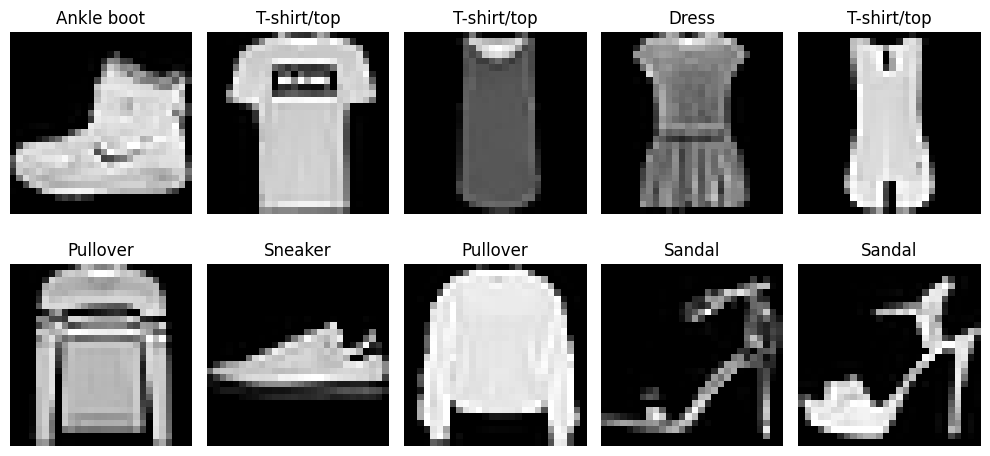

In [5]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

**Verificación de balance de clases**

Se revisa que todas las clases tengan una cantidad similar de ejemplos. Si están balanceadas, el
accuracy es una métrica confiable y no hace falta compensar clases con menos ejemplos.

In [6]:
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"{class_names[cls]}: {count} ejemplos")

T-shirt/top: 6000 ejemplos
Trouser: 6000 ejemplos
Pullover: 6000 ejemplos
Dress: 6000 ejemplos
Coat: 6000 ejemplos
Sandal: 6000 ejemplos
Shirt: 6000 ejemplos
Sneaker: 6000 ejemplos
Bag: 6000 ejemplos
Ankle boot: 6000 ejemplos


## 3. Preprocesamiento

**Normalización de píxeles**

Los píxeles van de 0 a 255 y se dividen por 255 para dejarlos entre 0 y 1. Con valores grandes,
las sumas dentro de la red también crecen y el entrenamiento se vuelve inestable. Además, Keras
inicializa los pesos pensando en entradas pequeñas.

Se eligió dividir por 255 en vez de estandarizar porque funciona igual de bien con imágenes y
mantiene el significado de cada valor (0 es negro y 1 es blanco).

In [7]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

**Aplanar las imágenes**

Una capa densa **(Dense)** recibe vectores y no matrices, por lo tanto, cada imagen de 28x28 se
convierte en un vector de 784 valores (uno por píxel).

Esta decisión implica que **se pierde la estructura espacial**, entonces, la
red ya no sabe qué píxeles eran vecinos y tiene que aprender la relación entre ellos con solo ver
los datos. Esta limitación explica gran parte de los errores del modelo entre prendas que tengan silueta parecida, como se analiza en las secciones de evaluación.

In [8]:
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

print("Nueva forma X_train:", X_train.shape)  # (60000, 784)
print("Nueva forma X_test:", X_test.shape)    # (10000, 784)

Nueva forma X_train: (60000, 784)
Nueva forma X_test: (10000, 784)


**Separar un set de validación**

Se separa el 10% del conjunto de entrenamiento (6.000 imágenes) como **validación**. Cada
conjunto cumple un rol distinto:


| Conjunto | Tamaño | Uso |
|---|---|---|
| Entrenamiento | 54.000 | Ajustar los pesos de la red |
| Validación | 6.000 | Monitorear el sobreajuste y comparar configuraciones |
| Prueba | 10.000 | Estimar el desempeño final, sin intervenir en ninguna decisión |


- `stratify=y_train` asegura que la proporción de clases en validación sea igual a la de
  entrenamiento, evitando sesgos en la evaluación.
- `random_state=42` fija la partición, de modo que todas las ejecuciones y todos los
  experimentos usan exactamente los mismos datos.

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print("Train:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)

Train: (54000, 784) (54000,)
Validación: (6000, 784) (6000,)


In [10]:
print(y_train[:10]) #muestra los primeros 10 valores de y_train

[8 9 8 0 1 9 4 6 6 8]


**Decisión: etiquetas enteras con `sparse_categorical_crossentropy`**

>Se optó por mantener las etiquetas en formato entero (sin *one-hot encoding*), utilizando la función de pérdida `sparse_categorical_crossentropy`. Esta alternativa es matemáticamente equivalente a `categorical_crossentropy` con etiquetas *one-hot*, pero resulta más eficiente en memoria y reduce el riesgo de errores de codificación, siendo el enfoque recomendado por la documentación oficial de Keras para problemas de clasificación multiclase con etiquetas enteras.

## 4. Funciones de la red y modelo base

### 4.1 Funciones de activación, pérdida y salida

Antes de usar las funciones de Keras, se programan en NumPy a partir de su fórmula y se comprueba
que den el mismo resultado que TensorFlow.

| Función | Rol en la red | Fórmula |
|---|---|---|
| ReLU | Activación oculta | `max(0, z)` |
| Sigmoid | Activación oculta (alternativa) | `1 / (1 + e^(-z))` |
| Tanh | Activación oculta (alternativa) | `(e^z - e^(-z)) / (e^z + e^(-z))` |
| ELU | Activación oculta (alternativa) | `z` si `z > 0`, y `e^z - 1` si no |
| Softmax | Salida | `e^(z_i) / Σ_j e^(z_j)` |
| Entropía cruzada | Pérdida (error) | `-ln(p_clase_correcta)` |

In [11]:
# ---- Activaciones y sus derivadas ----
def relu(z):
    return np.maximum(0, z)

def relu_derivada(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivada(z):
    s = sigmoid(z)
    return s * (1 - s)          # máximo 0.25, en z = 0

def tanh(z):
    return np.tanh(z)

def tanh_derivada(z):
    return 1 - np.tanh(z) ** 2  # máximo 1, en z = 0

def elu(z):
    return np.where(z > 0, z, np.exp(z) - 1)

def elu_derivada(z):
    return np.where(z > 0, 1.0, np.exp(z))


# ---- Salida ----
def softmax(z):
    """Convierte logits en probabilidades que suman 1 (por fila).

    Se resta el máximo de cada fila antes de exponenciar: el resultado matemático no cambia,
    pero evita desbordes numéricos con logits grandes (e^1000 = inf).
    """
    z = z - np.max(z, axis=-1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=-1, keepdims=True)


# ---- Pérdida ----
def sparse_cross_entropy(y_true, probs, eps=1e-7):
    """Entropía cruzada media con etiquetas enteras: -ln(probabilidad de la clase correcta).

    Las probabilidades se acotan a [eps, 1 - eps] para evitar ln(0) = -inf, igual que Keras.
    """
    p_correcta = np.clip(probs[np.arange(len(y_true)), y_true], eps, 1 - eps)
    return -np.mean(np.log(p_correcta))

**Prueba de las funciones:** se aplican las funciones propias y las de TensorFlow a los mismos
datos. Si la diferencia máxima es del orden de 1e-7 (la precisión de `float32`), calculan lo
mismo.

In [12]:
rng = np.random.default_rng(SEED)
z = rng.normal(0, 3, size=(1000, 10)).astype('float32')   # logits aleatorios de 10 clases
y = rng.integers(0, 10, size=1000)                         # etiquetas aleatorias

pruebas = [
    ('ReLU',             relu(z),                     tf.nn.relu(z).numpy()),
    ('Sigmoid',          sigmoid(z),                  tf.nn.sigmoid(z).numpy()),
    ('Tanh',             tanh(z),                     tf.nn.tanh(z).numpy()),
    ('ELU',              elu(z),                      tf.nn.elu(z).numpy()),
    ('Softmax',          softmax(z),                  tf.nn.softmax(z).numpy()),
    ('Entropía cruzada', sparse_cross_entropy(y, softmax(z)),
                         tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(
                             y, tf.nn.softmax(z))).numpy()),
]

for nombre, propia, keras in pruebas:
    dif = np.max(np.abs(np.asarray(propia) - np.asarray(keras)))
    print(f"{nombre:<17} diferencia máxima = {dif:.2e}   {'OK' if dif < 1e-5 else 'REVISAR'}")

ReLU              diferencia máxima = 0.00e+00   OK
Sigmoid           diferencia máxima = 1.79e-07   OK
Tanh              diferencia máxima = 2.38e-07   OK
ELU               diferencia máxima = 1.19e-07   OK
Softmax           diferencia máxima = 2.38e-07   OK
Entropía cruzada  diferencia máxima = 0.00e+00   OK


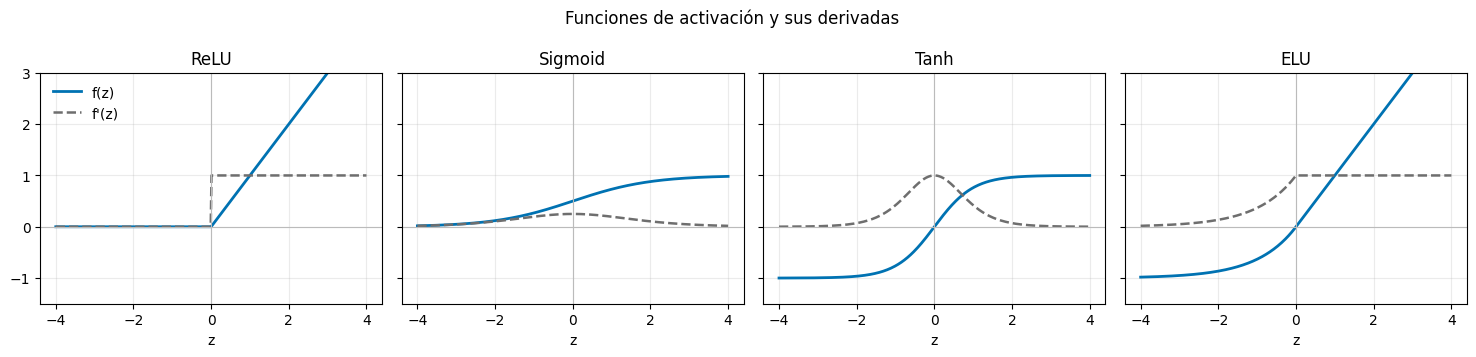

In [13]:
# Forma de cada activación (línea sólida) y de su derivada (línea punteada).
# La derivada es lo que se propaga hacia atrás durante el entrenamiento.
zs = np.linspace(-4, 4, 400)
activaciones = [('ReLU', relu, relu_derivada), ('Sigmoid', sigmoid, sigmoid_derivada),
                ('Tanh', tanh, tanh_derivada), ('ELU', elu, elu_derivada)]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, (nombre, f, df) in zip(axes, activaciones):
    ax.plot(zs, f(zs), color='#0072B2', lw=2, label='f(z)')
    ax.plot(zs, df(zs), color='#6E6E6E', lw=1.8, ls='--', label="f'(z)")
    ax.axhline(0, color='#BBBBBB', lw=0.8)
    ax.axvline(0, color='#BBBBBB', lw=0.8)
    ax.set_title(nombre)
    ax.set_xlabel('z')
    ax.set_ylim(-1.5, 3)
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False, loc='upper left')
fig.suptitle('Funciones de activación y sus derivadas')
fig.tight_layout()
plt.show()

In [14]:
# Ejemplo 1 - softmax y entropía cruzada con tres logits
logits = np.array([[2.0, 1.0, 0.1]])
p = softmax(logits)[0]
print("Logits:        ", logits[0])
print("Probabilidades:", p.round(3), "| suma =", p.sum().round(3))
print(f"Pérdida si la clase correcta es la 0: {sparse_cross_entropy(np.array([0]), p[None]):.3f}")
print(f"Pérdida si la clase correcta es la 2: {sparse_cross_entropy(np.array([2]), p[None]):.3f}")
print(f"Pérdida de un modelo que adivina al azar entre 10 clases: {-np.log(1/10):.3f}")

# Ejemplo 2 - atenuación del gradiente: producto de las derivadas máximas a través de n capas
print("\nFactor máximo que conserva el gradiente tras n capas ocultas:")
for n in [1, 2, 3, 5]:
    print(f"  {n} capas -> sigmoid: {0.25 ** n:.4f}   tanh / ReLU / ELU: {1.0 ** n:.1f}")

Logits:         [2.  1.  0.1]
Probabilidades: [0.659 0.242 0.099] | suma = 1.0
Pérdida si la clase correcta es la 0: 0.417
Pérdida si la clase correcta es la 2: 2.317
Pérdida de un modelo que adivina al azar entre 10 clases: 2.303

Factor máximo que conserva el gradiente tras n capas ocultas:
  1 capas -> sigmoid: 0.2500   tanh / ReLU / ELU: 1.0
  2 capas -> sigmoid: 0.0625   tanh / ReLU / ELU: 1.0
  3 capas -> sigmoid: 0.0156   tanh / ReLU / ELU: 1.0
  5 capas -> sigmoid: 0.0010   tanh / ReLU / ELU: 1.0


**Interpretación:**

- **Softmax** convierte los logits `[2.0, 1.0, 0.1]` en probabilidades `[0.659, 0.242, 0.099]`,
  que suman 1. Es la salida adecuada porque cada prenda pertenece a una sola clase.
- **La entropía cruzada** vale 0.417 si la red le da 65.9% a la clase correcta y 2.317 si le da
  9.9%, así que castiga fuerte los errores cometidos con seguridad. Adivinar al azar entre 10
  clases da 2.303, un valor útil como referencia al leer las curvas.
- **La derivada de sigmoid es como máximo 0.25**, así que el gradiente se reduce al menos a la
  cuarta parte en cada capa (0.0625 con dos capas). En ReLU, tanh y ELU llega a 1. Por eso se usa
  ReLU en las capas ocultas, y en la sección 9 se compara experimentalmente.

### 4.2 Arquitectura del modelo base

| Capa | Neuronas | Activación | Función |
|---|---|---|---|
| Entrada | 784 | - | Una neurona por píxel |
| Oculta 1 | 256 | ReLU | Combina los píxeles en patrones simples |
| Dropout | - | - | Desactiva el 30% de las neuronas al entrenar |
| Oculta 2 | 128 | ReLU | Combina esos patrones en rasgos más complejos |
| Dropout | - | - | Desactiva el 30% de las neuronas al entrenar |
| Salida | 10 | Softmax | Una neurona por clase |

- **Dos capas ocultas (256 y 128):** van reduciendo la información hacia las 10 clases. Se
  compara con otras arquitecturas en el experimento 7.
- **ReLU:** su derivada vale 1 en la zona activa, así que no atenúa el gradiente (sección 4.1).
- **Dropout 0.3:** el modelo tiene 235.146 parámetros para 54.000 ejemplos, así que puede
  memorizar. 0.3 es un valor moderado (lo habitual es entre 0.2 y 0.5). Se evalúa en el
  experimento 6.
- **Softmax:** las 10 clases son mutuamente excluyentes.

In [15]:
# Semilla fija justo antes de crear el modelo: misma inicialización de pesos
# y mismas máscaras de dropout en cada ejecución
tf.keras.utils.set_random_seed(SEED)

model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

**Compilación**

- **Adam con `learning_rate=0.001`:** ajusta el paso de cada peso según sus gradientes recientes,
  por lo que converge rápido sin mucha configuración. 0.001 es el valor recomendado por sus
  autores. Se escribe explícito para poder cambiarlo en el experimento 1.
- **`sparse_categorical_crossentropy`:** entropía cruzada para clasificación multiclase con
  etiquetas enteras.
- **`accuracy`:** sirve para seguir el entrenamiento porque las clases están balanceadas. Al
  final se agregan precision, recall y F1.

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.001),  # tasa de aprendizaje explícita
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Entrenamiento**

- **30 épocas:** suficiente para ver la convergencia y el inicio del sobreajuste. Se revisa en el
  experimento 3.
- **Batch de 32:** valor habitual, que da 1.688 actualizaciones por época. Se revisa en el
  experimento 2.
- **`validation_data`:** mide el desempeño en cada época con datos que la red no usa para
  aprender.

In [17]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7883 - loss: 0.5914 - val_accuracy: 0.8493 - val_loss: 0.4094
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8389 - loss: 0.4439 - val_accuracy: 0.8652 - val_loss: 0.3716
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8525 - loss: 0.4037 - val_accuracy: 0.8747 - val_loss: 0.3451
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8600 - loss: 0.3846 - val_accuracy: 0.8785 - val_loss: 0.3329
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8661 - loss: 0.3659 - val_accuracy: 0.8758 - val_loss: 0.3403
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8715 - loss: 0.3524 - val_accuracy: 0.8825 - val_loss: 0.3168
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8726 - loss: 0.3443 - val_accuracy: 0.8835 - val_loss: 0.3299
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8756 - loss: 0.3335 - 

**Graficos de las curvas de entrenamiento**

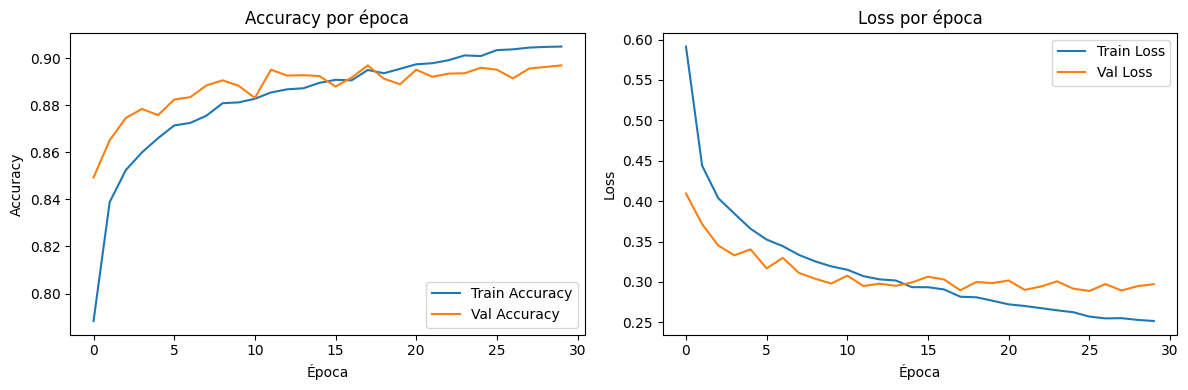

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Accuracy por época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss por época')
plt.legend()

plt.tight_layout()
plt.show()

**Evaluación inicial en el set de test**

Sirve como punto de partida. Los experimentos siguientes se comparan solo con validación, así
que el test no influye en la elección de hiperparámetros.

In [19]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8829
Test Loss: 0.3505


**Métricas del modelo y matriz de confusión**

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.79      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.76      0.79      1000
       Dress       0.83      0.93      0.88      1000
        Coat       0.80      0.81      0.80      1000
      Sandal       0.96      0.97      0.97      1000
       Shirt       0.68      0.73      0.70      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.99      0.95      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



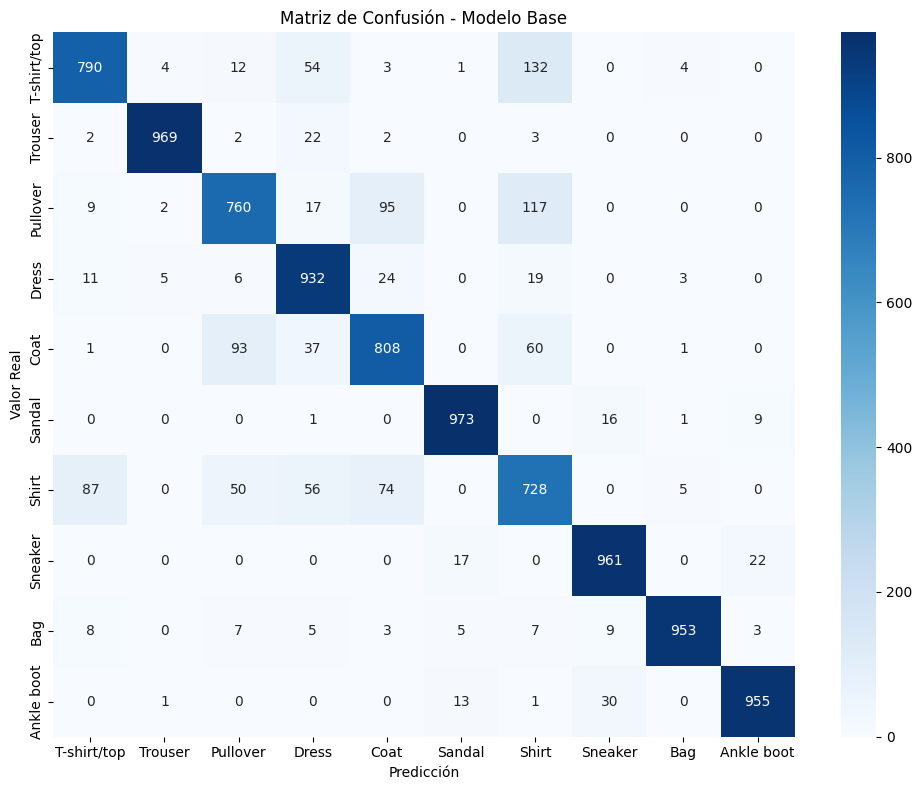

In [20]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Modelo Base')
plt.tight_layout()
plt.show()

## Interpretación de Resultados - Modelo Base

### Métricas generales

El modelo base (MLP con arquitectura 256-128-10, dropout 0.3, 30 épocas, batch size 32)
alcanzó un **accuracy de test de 88.29%**, con un F1-score promedio (macro) de 0.88.

### Análisis por clase

El desempeño no es uniforme entre las 10 clases. Se observan dos grupos claramente diferenciados:

**Clases con buen desempeño (F1 ≥ 0.95):**
- Trouser (0.98), Sandal (0.97), Bag (0.97), Ankle boot (0.96), Sneaker (0.95)

Estas categorías tienen formas muy distintivas y fácilmente separables del resto
(ej. un pantalón no se parece a un zapato), lo que explica su alto rendimiento.

**Clases con desempeño más débil (F1 ≤ 0.83):**
- Shirt (0.70), Pullover (0.79), Coat (0.80), T-shirt/top (0.83)

### Patrón de errores

Las cuatro clases más débiles corresponden a prendas de la parte superior del cuerpo (Shirt,
Pullover, Coat, T-shirt/top). En las cuatro, tanto precision como recall quedan por debajo de
0.83, mientras que el resto de las clases supera 0.95 en ambas métricas — una diferencia grande
y consistente, no un caso aislado.

- **Shirt** es la más débil: precision 0.68, recall 0.73.
- **Pullover** y **Coat** están en un rango parecido (precision 0.80-0.82, recall 0.76-0.81).
- **T-shirt/top** tiene mejor precision (0.87) pero recall bajo (0.79), es decir, cuando el
  modelo predice T-shirt/top suele acertar, pero le cuesta reconocer todas las T-shirt/top reales.

(El detalle exacto de qué clase se confunde con cuál está en el mapa de calor de la celda
anterior; los números de arriba salen del reporte de `classification_report`.)

### Interpretación

El patrón de errores es consistente con una limitación estructural del MLP: al aplanar
cada imagen 28x28 en un vector de 784 valores, **se pierde toda la información espacial**
(relación entre píxeles vecinos). Prendas como Shirt, Pullover, Coat y T-shirt/top
comparten una silueta rectangular muy similar, diferenciándose principalmente por
detalles finos (cuello, mangas, textura, largo) que dependen de relaciones espaciales
locales entre píxeles — información que el MLP no puede aprovechar de la misma forma
que lo haría una arquitectura convolucional (CNN).

## 5. Protocolo experimental

Todos los experimentos siguen las mismas reglas:

1. **Un solo cambio por experimento:** se parte de la configuración del modelo base (256-128,
   ReLU, dropout 0.3, Adam 0.001, batch 32, 30 épocas) y se cambia un elemento. Así la
   diferencia se puede atribuir a ese cambio.
2. **Semilla fija (42):** todas las corridas parten de los mismos pesos iniciales y del mismo
   orden de datos, para que el azar no se confunda con el efecto del cambio.
3. **Selección con validación:** el test solo se usa para evaluar el modelo final.
4. **Entrenamientos diferenciados:** cada experimento guarda su modelo y su historial en
   `model_<nombre>` y `history_<nombre>`. El modelo base conserva `model` y `history`.
5. **Registro:** cada corrida agrega una fila a una tabla común, de donde salen las tablas y
   los gráficos.

### 5.1 Funciones de apoyo

- `build_model(...)`: crea un MLP nuevo. Por defecto es igual al modelo base, así que cada
  experimento solo indica lo que cambia.
- `run_experiment(...)`: compila, entrena, mide el tiempo y registra el resultado.
- `registrar(...)`: agrega una fila a la tabla de resultados.
- `comparar(...)`, `resumen_puntos(...)` y `tabla(...)`: generan los gráficos y las tablas.

| Columna | Significado |
|---|---|
| `val_acc_max` | Mejor accuracy en validación |
| `val_loss_min` | Menor pérdida en validación |
| `mejor_epoca` | Época en que se alcanzó `val_loss_min` |
| `train_acc_final` | Accuracy de entrenamiento en la última época |
| `brecha` | `train_acc_final - val_acc_final`, mide el sobreajuste |
| `seg` | Tiempo de entrenamiento en segundos |

In [21]:
import time
import pandas as pd
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Paleta categórica Okabe-Ito: distinguible con los tres tipos de daltonismo.
# El modelo base se dibuja siempre en gris punteado: es la referencia, no una categoría más.
PALETA = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7']
GRIS_REF = '#6E6E6E'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,        # grilla discreta, para no competir con los datos
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

RESULTADOS = []   # una fila por experimento
HISTORIAS = {}    # nombre del experimento -> objeto History de Keras


def build_model(units=(256, 128), activation='relu', dropout=0.3,
                l2=0.0, batchnorm=False, seed=SEED):
    """Construye un MLP nuevo. Los valores por defecto reproducen el modelo base.

    units      : neuronas de cada capa oculta
    activation : función de activación de las capas ocultas
    dropout    : fracción de neuronas desactivadas en entrenamiento (0.0 = sin dropout)
    l2         : coeficiente de regularización L2 sobre los pesos (0.0 = sin L2)
    batchnorm  : agrega BatchNormalization después de cada capa oculta
    """
    tf.keras.utils.set_random_seed(seed)  # misma inicialización que el modelo base

    capas = [Input(shape=(784,))]
    for n in units:
        capas.append(Dense(
            n, activation=activation,
            kernel_regularizer=regularizers.l2(l2) if l2 else None
        ))
        if batchnorm:
            capas.append(BatchNormalization())
        if dropout:
            capas.append(Dropout(dropout))
    capas.append(Dense(10, activation='softmax'))  # 10 clases mutuamente excluyentes
    return Sequential(capas)


def registrar(nombre, bloque, config, hist, seg=None):
    """Agrega una fila de resultados a partir del historial de entrenamiento."""
    h = hist.history
    mejor = int(np.argmin(h['val_loss'])) + 1  # +1: las épocas se cuentan desde 1
    RESULTADOS.append({
        'experimento': nombre,
        'bloque': bloque,
        'config': config,
        'val_acc_max': round(max(h['val_accuracy']), 4),
        'val_loss_min': round(min(h['val_loss']), 4),
        'mejor_epoca': mejor,
        'train_acc_final': round(h['accuracy'][-1], 4),
        'brecha': round(h['accuracy'][-1] - h['val_accuracy'][-1], 4),
        'epocas': len(h['loss']),
        'seg': None if seg is None else round(seg, 1),
    })
    HISTORIAS[nombre] = hist
    print(f"{nombre:<14} val_acc_max={max(h['val_accuracy']):.4f}  "
          f"val_loss_min={min(h['val_loss']):.4f} (época {mejor})"
          + ('' if seg is None else f"  {seg:.0f}s"))


def run_experiment(nombre, bloque, modelo, config, learning_rate=0.001,
                   loss='sparse_categorical_crossentropy', epochs=30, batch_size=32,
                   y_tr=None, y_va=None, callbacks=None):
    """Compila, entrena y registra un experimento. Devuelve (modelo, history)."""
    modelo.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=['accuracy']
    )
    t0 = time.time()
    hist = modelo.fit(
        X_train, y_train if y_tr is None else y_tr,
        validation_data=(X_val, y_val if y_va is None else y_va),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=0
    )
    registrar(nombre, bloque, config, hist, time.time() - t0)
    return modelo, hist


def _estilo(nombre, i):
    """Color y trazo de cada serie: el base siempre gris punteado, el resto en orden fijo."""
    if nombre == 'base':
        return {'color': GRIS_REF, 'linestyle': '--', 'linewidth': 2}
    return {'color': PALETA[i % len(PALETA)], 'linewidth': 2}


def comparar(nombres, titulo, metrica='loss'):
    """Superpone las curvas de entrenamiento y validación de varios experimentos."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    i = 0
    for nombre in nombres:
        h = HISTORIAS[nombre].history
        ep = range(1, len(h['loss']) + 1)
        estilo = _estilo(nombre, i)
        i += 0 if nombre == 'base' else 1
        axes[0].plot(ep, h[metrica], label=nombre, **estilo)
        axes[1].plot(ep, h['val_' + metrica], label=nombre, **estilo)
    axes[0].set_title('Entrenamiento')
    axes[1].set_title('Validación')
    axes[0].set_ylabel(metrica)
    for ax in axes:
        ax.set_xlabel('Época')
    axes[1].legend(frameon=False)  # una sola leyenda: ambos paneles usan los mismos colores
    fig.suptitle(titulo)
    fig.tight_layout()
    plt.show()


def resumen_puntos(df, titulo, metrica='val_acc_max'):
    """Gráfico de puntos para comparar experimentos.

    Se usan puntos y no barras porque el eje no parte de cero: con accuracies
    cercanos a 0.88, barras desde cero se verían prácticamente idénticas.
    """
    df = df.sort_values(metrica)
    fig, ax = plt.subplots(figsize=(8, 0.45 * len(df) + 1.5))
    colores = [GRIS_REF if n == 'base' else PALETA[0] for n in df['experimento']]
    ax.scatter(df[metrica], df['experimento'], color=colores, s=70, zorder=3)

    if 'base' in set(df['experimento']):  # referencia visual: el modelo base
        ref = df.loc[df['experimento'] == 'base', metrica].iloc[0]
        ax.axvline(ref, color=GRIS_REF, ls='--', lw=1, zorder=1)

    for v, n in zip(df[metrica], df['experimento']):   # etiqueta directa en cada punto
        ax.annotate(f'{v:.4f}', (v, n), xytext=(8, 0), textcoords='offset points',
                    va='center', fontsize=9, color='#333333')

    ax.set_xlabel(metrica)
    ax.margins(x=0.18)
    ax.grid(axis='y', alpha=0.15)
    ax.set_title(titulo)
    fig.tight_layout()
    plt.show()


def tabla(bloque=None):
    """Tabla de resultados ordenada por accuracy de validación, opcionalmente por bloque."""
    df = pd.DataFrame(RESULTADOS)
    if bloque is not None:
        df = df[df['bloque'] == bloque]
    return df.sort_values('val_acc_max', ascending=False).reset_index(drop=True)

### 5.2 Registro del modelo base como referencia

El modelo base de la sección 4 se entrenó con la misma semilla y configuración que usa
`build_model()` por defecto, así que no se reentrena: solo se registra su historial.

En sus curvas, la pérdida de validación es menor que la de entrenamiento durante las primeras
épocas. Esto pasa porque el dropout solo se aplica al entrenar, y la validación usa la red
completa.

In [22]:
registrar('base', '0-base',
          '256-128 | relu | dropout 0.3 | lr 0.001 | batch 32 | 30 épocas', history)

base           val_acc_max=0.8970  val_loss_min=0.2888 (época 26)


## 6. Experimento 1: Tasa de aprendizaje

**Hipótesis:** la tasa de aprendizaje es el tamaño del paso en cada actualización de pesos.

- Con `0.01` se espera una curva inestable, porque los pasos son tan grandes que se pasan del
  mínimo.
- Con `0.0001` se espera una curva suave pero lenta, que quizás no alcance a converger en
  30 épocas.
- `0.001` debería ser el mejor equilibrio.

In [23]:
model_lr_alto, history_lr_alto = run_experiment(
    nombre='lr_alto', bloque='1-learning_rate', modelo=build_model(),
    learning_rate=0.01, config='lr 0.01'
)

model_lr_bajo, history_lr_bajo = run_experiment(
    nombre='lr_bajo', bloque='1-learning_rate', modelo=build_model(),
    learning_rate=0.0001, config='lr 0.0001'
)

lr_alto        val_acc_max=0.7762  val_loss_min=0.5590 (época 22)  90s
lr_bajo        val_acc_max=0.9040  val_loss_min=0.2670 (época 29)  86s


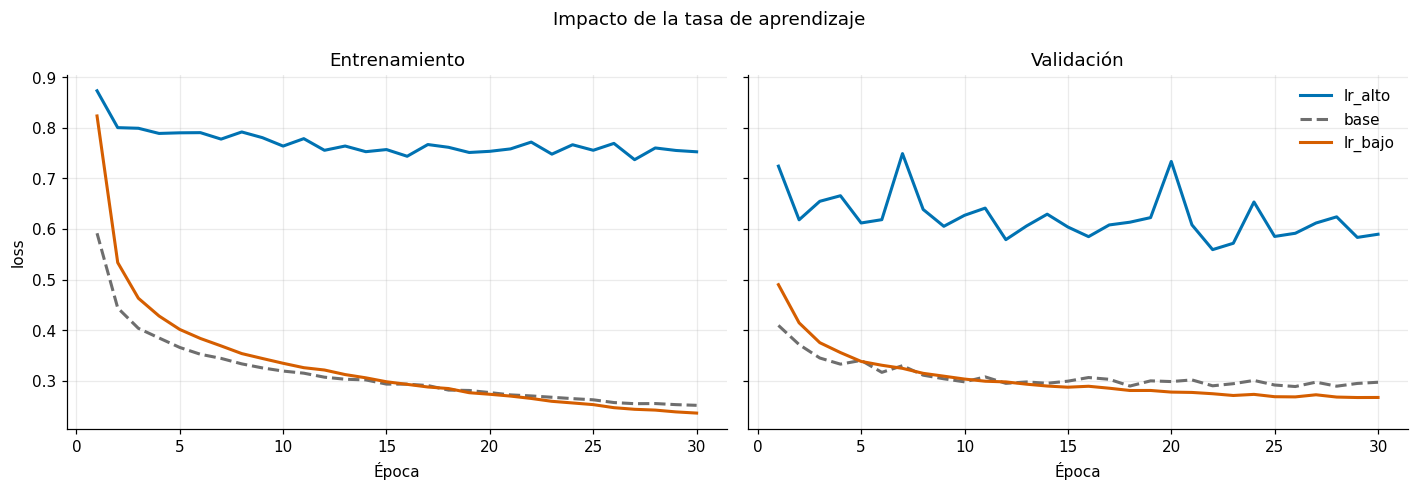

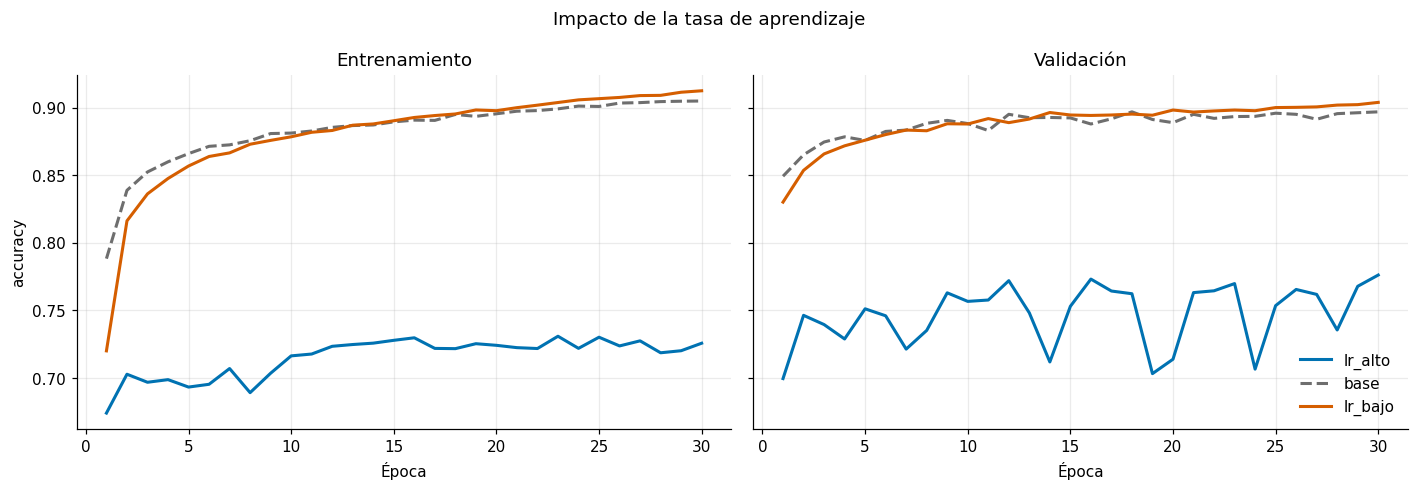

,experimento,bloque,config,val_acc_max,val_loss_min,mejor_epoca,train_acc_final,brecha,epocas,seg
0,base,0-base,256-128 | relu | dropout 0.3 | lr 0.001 | batc...,0.8970,0.2888,26,0.9050,0.0080,30,NaN
0,lr_bajo,1-learning_rate,lr 0.0001,0.9040,0.2670,29,0.9126,0.0086,30,86.1
1,lr_alto,1-learning_rate,lr 0.01,0.7762,0.5590,22,0.7257,-0.0505,30,89.7


In [24]:
comparar(['lr_alto', 'base', 'lr_bajo'], 'Impacto de la tasa de aprendizaje', metrica='loss')
comparar(['lr_alto', 'base', 'lr_bajo'], 'Impacto de la tasa de aprendizaje', metrica='accuracy')

pd.concat([tabla('0-base'), tabla('1-learning_rate')])

### Análisis del experimento 1

**Resultados:**

| Tasa de aprendizaje | `val_acc_max` | `val_loss_min` (época) | `train_acc_final` | `brecha` |
|---|---|---|---|---|
| 0.01 | 0.7762 | 0.5590 (22) | 0.7257 | -0.0505 |
| 0.001 (base) | 0.8970 | 0.2888 (26) | 0.9050 | 0.0080 |
| 0.0001 | **0.9040** | **0.2670** (29) | 0.9126 | 0.0086 |

- `lr = 0.01` no converge: el accuracy de entrenamiento ni siquiera llega a 0.73 y la brecha es
  negativa (-0.0505), es decir, el modelo rinde peor en entrenamiento que en validación — señal
  de que los pasos son tan grandes que la red nunca se estabiliza.
- `lr = 0.0001` parte más lento, pero converge de forma más suave y termina siendo la mejor
  configuración del experimento, con +0.70 puntos sobre el base y la menor pérdida de validación.

**¿Se cumplió lo esperado?** En parte. La tasa alta fue inestable, como se esperaba. La baja fue
lenta al inicio, pero sí convergió en 30 épocas y terminó mejor que el base.

**Decisión:** se mantiene `0.001`. La mejora de `0.0001` es real pero modesta, y en el modelo
final se usa un batch 4 veces mayor, que reduce las actualizaciones por época. Con ambos cambios
juntos, el modelo probablemente quedaría subentrenado.

## 7. Experimento 2: Tamaño del batch

**Hipótesis:** el batch es la cantidad de imágenes que se usan antes de cada actualización. Con
54.000 imágenes hay 3.375 actualizaciones por época con batch 16, 1.688 con 32, 422 con 128 y
106 con 512.

- Un batch pequeño debería dar curvas más ruidosas y épocas más lentas.
- Un batch grande debería ser más rápido y estable, pero podría necesitar más épocas.

También se compara el tiempo (`seg`), porque aquí cambia bastante.

In [25]:
model_batch_16, history_batch_16 = run_experiment(
    nombre='batch_16', bloque='2-batch_size', modelo=build_model(),
    batch_size=16, config='batch 16'
)

model_batch_128, history_batch_128 = run_experiment(
    nombre='batch_128', bloque='2-batch_size', modelo=build_model(),
    batch_size=128, config='batch 128'
)

model_batch_512, history_batch_512 = run_experiment(
    nombre='batch_512', bloque='2-batch_size', modelo=build_model(),
    batch_size=512, config='batch 512'
)

batch_16       val_acc_max=0.8968  val_loss_min=0.2997 (época 18)  130s
batch_128      val_acc_max=0.9042  val_loss_min=0.2784 (época 24)  33s
batch_512      val_acc_max=0.9048  val_loss_min=0.2696 (época 23)  17s


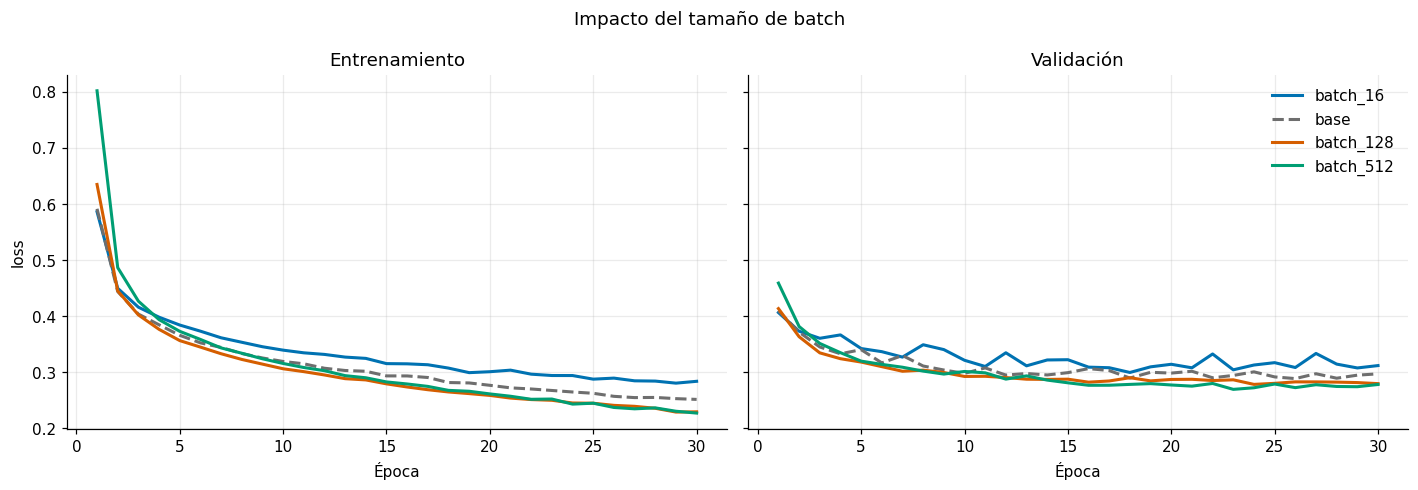

,experimento,bloque,config,val_acc_max,val_loss_min,mejor_epoca,train_acc_final,brecha,epocas,seg
0,batch_512,2-batch_size,batch 512,0.9048,0.2696,23,0.9136,0.0121,30,17.0
1,batch_128,2-batch_size,batch 128,0.9042,0.2784,24,0.9126,0.0084,30,33.5
2,batch_16,2-batch_size,batch 16,0.8968,0.2997,18,0.8954,-0.0015,30,130.5


In [26]:
comparar(['batch_16', 'base', 'batch_128', 'batch_512'],
         'Impacto del tamaño de batch', metrica='loss')

tabla('2-batch_size')

### Análisis del experimento 2

**Resultados:**

| Batch | Actualizaciones por época | `val_acc_max` | `val_loss_min` | Tiempo |
|---|---|---|---|---|
| 16 | 3.375 | 0.8968 | 0.2997 | 130 s |
| 32 (base) | 1.688 | 0.8970 | 0.2888 | ≈ 85 s* |
| 128 | 422 | 0.9042 | 0.2784 | 34 s |
| 512 | 106 | **0.9048** | **0.2696** | **17 s** |

<sub>\* El base no tiene tiempo registrado porque se entrenó en la sección 4. Como referencia se
usa el de los otros experimentos con batch 32 (entre 77 y 98 s).</sub>

- Batch 16 tiene la curva más irregular, el peor resultado del grupo y es el más lento (130 s).
- Batch 128 y 512 quedan prácticamente empatados (diferencia de solo 0.0006, dentro del margen de
  ruido esperado con una sola semilla) y muy por delante de batch 16 y del base.

**¿Se cumplió lo esperado?** Sí. El batch pequeño fue más ruidoso y lento, y el grande fue más
rápido sin perder precisión.

**Decisión:** batch 128. Prácticamente empatado con 512 en accuracy de validación, y sigue siendo
unas 2,5 veces más rápido que el batch original (32). Batch 512 sería una alternativa igual de
válida, más rápida todavía.

## 8. Experimento 3: Número de épocas

**Hipótesis:**

- Con 10 épocas el modelo debería quedar subentrenado.
- Con 50 épocas debería aparecer sobreajuste: la pérdida de entrenamiento sigue bajando y la de
  validación se estanca o sube.

Esto sirve para justificar el early stopping del experimento 6.

In [27]:
model_epocas_10, history_epocas_10 = run_experiment(
    nombre='epocas_10', bloque='3-epocas', modelo=build_model(),
    epochs=10, config='10 épocas'
)

model_epocas_50, history_epocas_50 = run_experiment(
    nombre='epocas_50', bloque='3-epocas', modelo=build_model(),
    epochs=50, config='50 épocas'
)

epocas_10      val_acc_max=0.8907  val_loss_min=0.2980 (época 10)  30s
epocas_50      val_acc_max=0.9035  val_loss_min=0.2888 (época 26)  145s


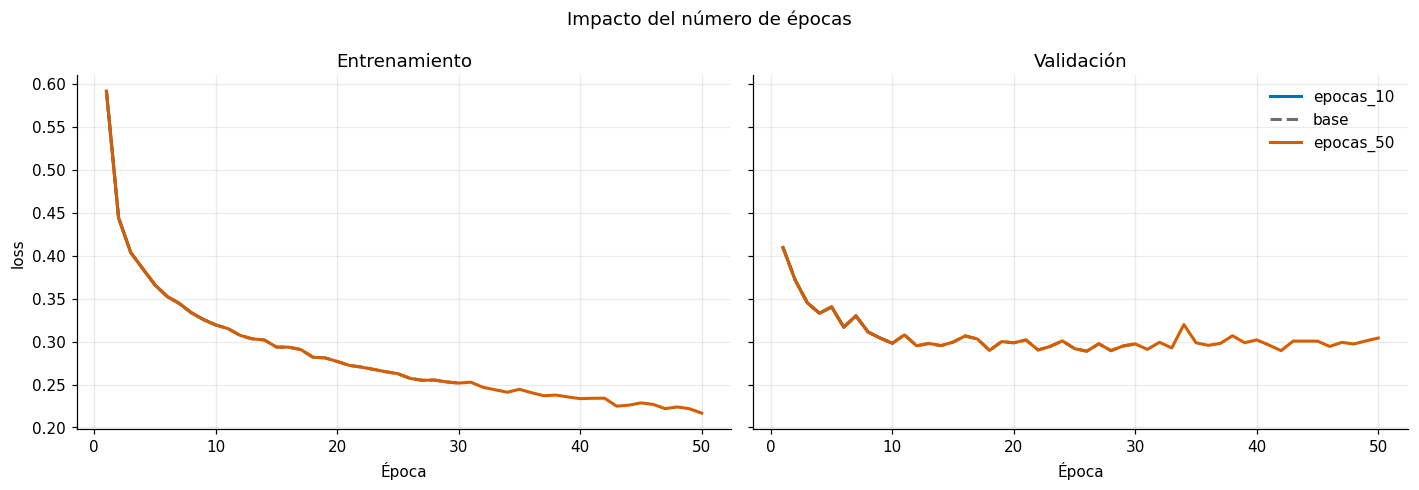

,experimento,val_acc_max,val_loss_min,mejor_epoca,train_acc_final,brecha
0,base,0.8970,0.2888,26,0.9050,0.0080
0,epocas_50,0.9035,0.2888,26,0.9184,0.0191
1,epocas_10,0.8907,0.2980,10,0.8813,-0.0071


In [28]:
comparar(['epocas_10', 'base', 'epocas_50'], 'Impacto del número de épocas', metrica='loss')

# La brecha entre entrenamiento y validación es el indicador directo de sobreajuste
pd.concat([tabla('0-base'), tabla('3-epocas')])[
    ['experimento', 'val_acc_max', 'val_loss_min', 'mejor_epoca', 'train_acc_final', 'brecha']]

### Análisis del experimento 3

**Resultados:**

| Épocas | `val_acc_max` | `val_loss_min` (época) | `train_acc_final` | `brecha` |
|---|---|---|---|---|
| 10 | 0.8907 | 0.2980 (10) | 0.8813 | -0.0071 |
| 30 (base) | 0.8970 | 0.2888 (26) | 0.9050 | 0.0080 |
| 50 | 0.9035 | 0.2888 (26) | 0.9184 | 0.0191 |

- Las tres curvas son idénticas en las épocas que comparten, porque parten de la misma semilla y
  del mismo modo determinista de TensorFlow. Esto confirma que los experimentos son reproducibles.
- Con 10 épocas, la mejor pérdida de validación está en la última época: el modelo seguía
  mejorando.
- Con 50 épocas, la mejor pérdida de validación se mantiene en la **misma época que en el base**
  (26): entrenar más allá de ese punto no mejora la validación, solo sigue bajando la pérdida de
  entrenamiento (de 0.30 a niveles más bajos) y duplica la brecha (de 0.0080 a 0.0191).

**¿Se cumplió lo esperado?** Sí. El de 10 épocas quedó corto, y el de 50 mostró sobreajuste
creciente después de la época 26, aunque contenido gracias al dropout.

**Decisión:** el modelo final usa hasta 50 épocas con early stopping, en vez de un número fijo,
ya que la validación deja de mejorar bastante antes de llegar a la época 50.

## 9. Experimento 4: Funciones de activación

**Hipótesis:** lo que más importa es la derivada de cada activación, porque determina cuánto
gradiente llega a las capas anteriores.

| Activación | Derivada máxima | Resultado esperado |
|---|---|---|
| ReLU | 1 (para x > 0) | Referencia |
| ELU | 1 | Parecida a ReLU, sin neuronas muertas |
| Tanh | 1 (en x = 0) | Se satura en los extremos |
| Sigmoid | 0.25 | La más lenta en converger |

Como la red tiene solo dos capas ocultas, las diferencias finales pueden ser pequeñas, así que
también se mira la velocidad en las primeras épocas.

In [29]:
model_tanh, history_tanh = run_experiment(
    nombre='tanh', bloque='4-activacion', modelo=build_model(activation='tanh'),
    config='activación tanh'
)

model_sigmoid, history_sigmoid = run_experiment(
    nombre='sigmoid', bloque='4-activacion', modelo=build_model(activation='sigmoid'),
    config='activación sigmoid'
)

model_elu, history_elu = run_experiment(
    nombre='elu', bloque='4-activacion', modelo=build_model(activation='elu'),
    config='activación elu'
)

tanh           val_acc_max=0.8960  val_loss_min=0.2935 (época 29)  88s
sigmoid        val_acc_max=0.9033  val_loss_min=0.2679 (época 26)  84s
elu            val_acc_max=0.9018  val_loss_min=0.2821 (época 30)  84s


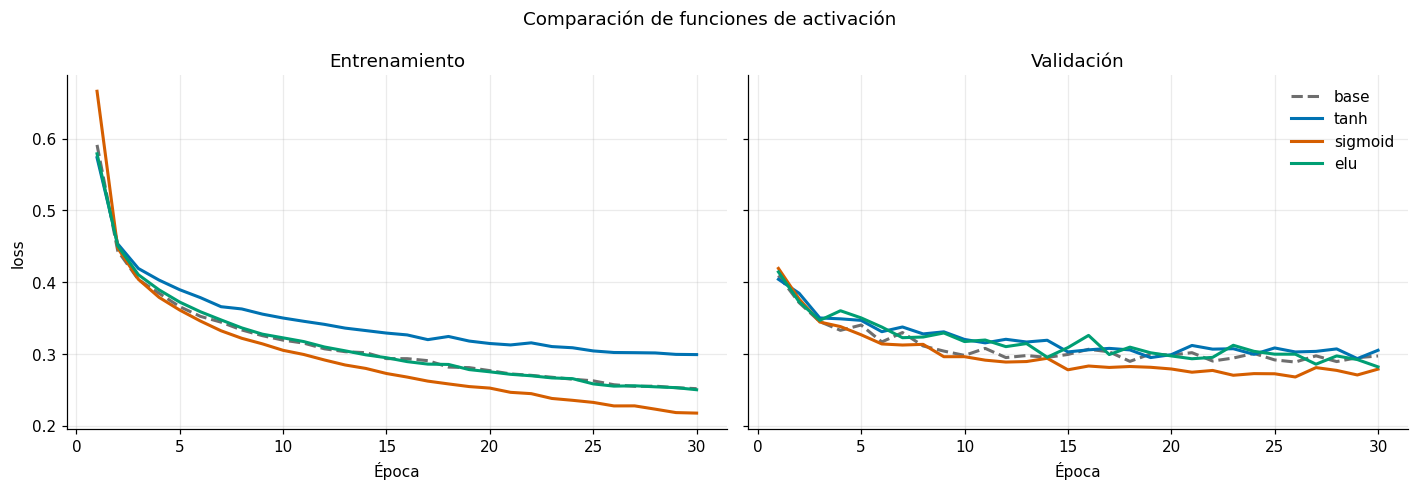

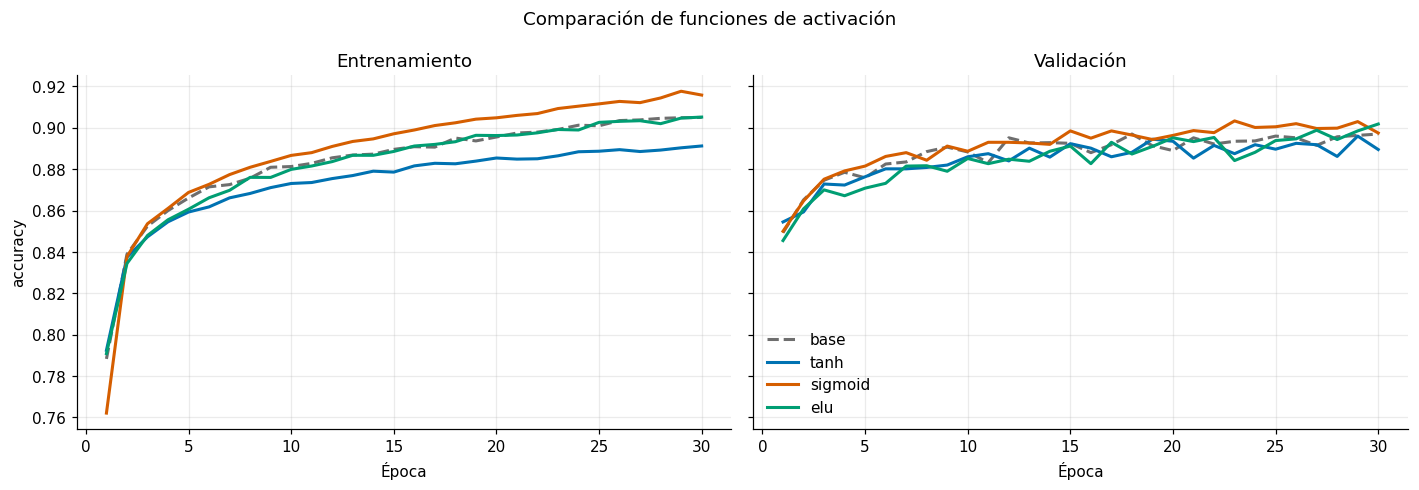

,experimento,config,val_acc_max,val_loss_min,mejor_epoca,brecha
0,base,256-128 | relu | dropout 0.3 | lr 0.001 | batc...,0.8970,0.2888,26,0.0080
0,sigmoid,activación sigmoid,0.9033,0.2679,26,0.0183
1,elu,activación elu,0.9018,0.2821,30,0.0034
2,tanh,activación tanh,0.8960,0.2935,29,0.0017


In [30]:
comparar(['base', 'tanh', 'sigmoid', 'elu'], 'Comparación de funciones de activación', metrica='loss')
comparar(['base', 'tanh', 'sigmoid', 'elu'], 'Comparación de funciones de activación', metrica='accuracy')

# Tabla comparativa de funciones de activación (exigida por la pauta)
pd.concat([tabla('0-base'), tabla('4-activacion')])[
    ['experimento', 'config', 'val_acc_max', 'val_loss_min', 'mejor_epoca', 'brecha']]

In [31]:
# Velocidad de convergencia: accuracy de validación alcanzado en distintas épocas
filas = []
for nombre in ['base', 'tanh', 'sigmoid', 'elu']:
    h = HISTORIAS[nombre].history['val_accuracy']
    filas.append({'activación': nombre if nombre != 'base' else 'relu (base)',
                  'época 1': round(h[0], 4), 'época 3': round(h[2], 4),
                  'época 5': round(h[4], 4), 'época 10': round(h[9], 4),
                  'época 30': round(h[29], 4)})
pd.DataFrame(filas)

,activación,época 1,época 3,época 5,época 10,época 30
0,relu (base),0.8493,0.8747,0.8758,0.8883,0.8970
1,tanh,0.8545,0.8728,0.8763,0.8860,0.8895
2,sigmoid,0.8500,0.8752,0.8815,0.8887,0.8975
3,elu,0.8455,0.8700,0.8708,0.8852,0.9018


### Análisis del experimento 4

**Resultados:**

| Activación | `val_acc_max` | `val_loss_min` | `brecha` |
|---|---|---|---|
| Sigmoid | **0.9033** | **0.2679** | 0.0183 |
| ELU | 0.9018 | 0.2821 | 0.0034 |
| ReLU (base) | 0.8970 | 0.2888 | 0.0080 |
| Tanh | 0.8960 | 0.2935 | **0.0017** |

Según la tabla de velocidad de convergencia (accuracy de validación por época), sigmoid también
es la más rápida al inicio: ya en la época 5 alcanza 0.8815, por delante de ELU (0.8708) y del
base (0.8758).

- Sigmoid tiene el mejor accuracy final del grupo, pero también la mayor brecha
  (0.0183) — indicio de que empieza a sobreajustar más que las demás.
- ELU queda segundo en accuracy (0.9018), con una brecha baja (0.0034), cercana a la de tanh
  (0.0017), que tiene el peor accuracy del grupo.
- Tanh converge más lento al inicio (época 1: 0.8545, la más alta de las cuatro, pero se estanca
  después) y termina con el peor resultado.

**¿Se cumplió lo esperado?** No del todo. Se esperaba que sigmoid fuera la más lenta por su
derivada máxima de 0.25, y en cambio fue la más rápida y la de mejor accuracy final. Hay tres
razones:

1. Con dos capas ocultas la atenuación es solo 0.0625. El problema aparece en redes más
   profundas.
2. Adam ajusta el paso de cada peso según el tamaño de sus gradientes, así que un gradiente
   pequeño igual produce un paso razonable.
3. Entre la mejor y la peor activación (sin contar tanh) hay solo 0.15 puntos, con una sola
   semilla. Buena parte de esa diferencia puede ser ruido.

**Decisión:** se mantiene ELU. Su accuracy es prácticamente igual al de sigmoid (diferencia de
0.0015, dentro del margen de ruido), pero con una brecha bastante menor — es decir, generaliza
mejor y es menos probable que dependa de las particularidades de esta semilla. Sigmoid sería una
alternativa razonable si se prioriza el accuracy puntual sobre el sobreajuste.

## 10. Experimento 5: Función de pérdida

**Hipótesis:** La **entropía cruzada** es la función ideal para clasificación, ya que mide la
probabilidad asignada a la clase correcta, `loss = -ln(p_correcta)`, y luego penaliza los
errores cometidos con mucha confianza.

El error cuadrático medio (MSE) está diseñado para regresión. Combinado con softmax, su
gradiente se vuelve pequeño justamente cuando la predicción está muy equivocada, lo que retrasa
la corrección de los errores más graves. Se espera una convergencia más lenta.

**Nota técnica:** MSE compara vectores de 10 componentes, por lo que requiere etiquetas
*one-hot*, mientras que `sparse_categorical_crossentropy` trabaja directamente con el entero de la clase. Es
la única diferencia de formato entre ambos experimentos.

In [32]:
y_train_oh = to_categorical(y_train, 10)
y_val_oh = to_categorical(y_val, 10)

model_mse, history_mse = run_experiment(
    nombre='mse', bloque='5-perdida', modelo=build_model(),
    loss='mse', y_tr=y_train_oh, y_va=y_val_oh,
    config='pérdida MSE con etiquetas one-hot'
)

mse            val_acc_max=0.8978  val_loss_min=0.0146 (época 27)  84s


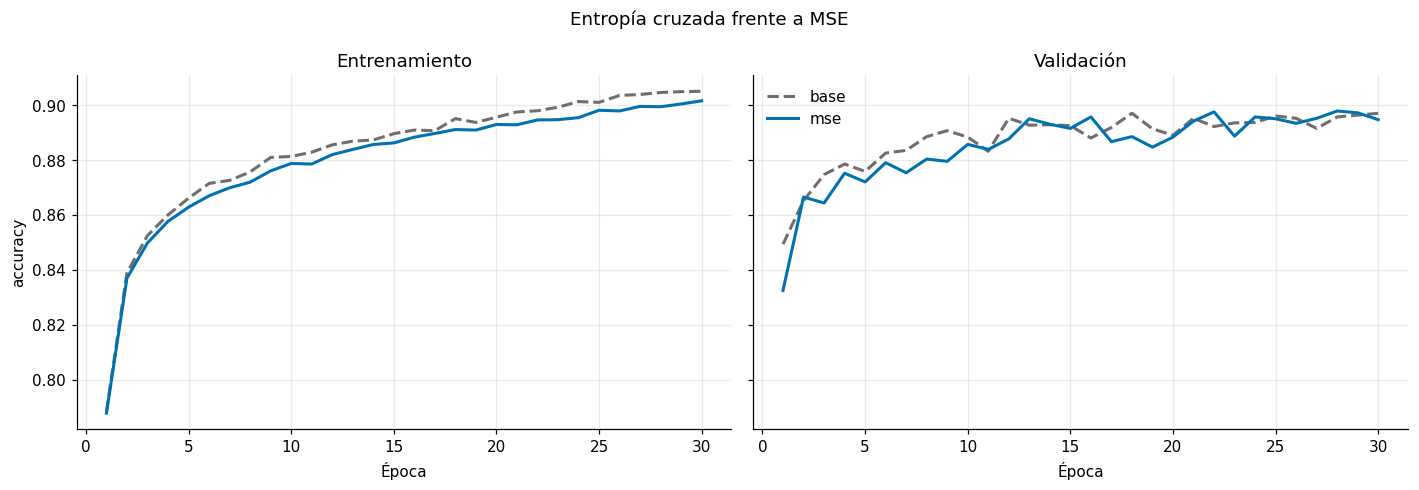

,experimento,config,val_acc_max,mejor_epoca
0,base,256-128 | relu | dropout 0.3 | lr 0.001 | batc...,0.8970,26
0,mse,pérdida MSE con etiquetas one-hot,0.8978,27


In [33]:
# Los valores de pérdida no son comparables entre sí (miden cosas distintas),
# así que la comparación válida es sobre el accuracy.
comparar(['base', 'mse'], 'Entropía cruzada frente a MSE', metrica='accuracy')

pd.concat([tabla('0-base'), tabla('5-perdida')])[
    ['experimento', 'config', 'val_acc_max', 'mejor_epoca']]

### Análisis del experimento 5

**Resultados:**

| Pérdida | `val_acc_max` | Mejor época |
|---|---|---|
| Entropía cruzada (base) | 0.8970 | 26 |
| MSE | 0.8978 | 27 |

- El accuracy final es prácticamente igual entre ambas (diferencia de 0.0008), dentro del margen
  de ruido esperado con una sola semilla.
- Los valores de pérdida no se pueden comparar directamente porque miden cosas distintas: la
  entropía cruzada es `-ln(probabilidad de la clase correcta)`, mientras que MSE mide la distancia
  cuadrática promedio contra el vector one-hot.

**¿Se cumplió lo esperado?** Solo en parte. Se esperaba que MSE convergiera más lento por el
problema teórico de gradiente saturado con softmax, pero en esta corrida terminó prácticamente
empatada con la entropía cruzada. Esto no contradice el argumento teórico —el problema de
gradiente saturado ocurre principalmente cuando la predicción está muy alejada de la correcta,
algo menos frecuente a medida que el modelo ya entrenó varias épocas—, pero sí muestra que el
efecto práctico en esta red es pequeño.

**Decisión:** se mantiene la entropía cruzada. No es por una ventaja de accuracy en esta corrida
(están empatadas), sino porque es la función que corresponde naturalmente a una salida softmax en
clasificación multiclase y no requiere convertir las etiquetas a one-hot.

## 11. Experimento 6: Técnicas de optimización y regularización

**Hipótesis:** El modelo base ya incluye dropout, por lo que se revisará la ejecución "con y sin
optimización" que pide la pauta para entrenar  una versión sin regularización.

| Variable | Mecanismo | Efecto esperado |
|---|---|---|
| `model_sin_dropout` | Sin regularización | Mayor accuracy de entrenamiento y mayor brecha con validación: sobreajuste más marcado |
| `model` (base) | Dropout 0.3 | Referencia |
| `model_l2` | Suma `λ·Σw²` a la pérdida, penalizando los pesos grandes | Pesos más pequeños y frontera de decisión más suave |
| `model_batchnorm` | Normaliza las activaciones en cada batch | Entrenamiento más estable y rápido en las primeras épocas |
| `model_earlystop` | Detiene el entrenamiento cuando la validación deja de mejorar | Evita las épocas improductivas y recupera los mejores pesos |

`EarlyStopping` usa `patience=5`, que tolera cinco épocas sin mejora antes de detener para no
reaccionar a fluctuaciones puntuales, y `restore_best_weights=True`, que devuelve los pesos de
la mejor época y no los de la última.

In [34]:
model_sin_dropout, history_sin_dropout = run_experiment(
    nombre='sin_dropout', bloque='6-regularizacion', modelo=build_model(dropout=0.0),
    config='sin dropout'
)

model_l2, history_l2 = run_experiment(
    nombre='l2', bloque='6-regularizacion', modelo=build_model(l2=1e-4),
    config='dropout 0.3 + L2 1e-4'
)

model_batchnorm, history_batchnorm = run_experiment(
    nombre='batchnorm', bloque='6-regularizacion', modelo=build_model(batchnorm=True),
    config='dropout 0.3 + BatchNormalization'
)

model_earlystop, history_earlystop = run_experiment(
    nombre='earlystop', bloque='6-regularizacion', modelo=build_model(), epochs=50,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    config='dropout 0.3 + early stopping (máx. 50 épocas)'
)

sin_dropout    val_acc_max=0.8958  val_loss_min=0.3096 (época 6)  77s
l2             val_acc_max=0.8903  val_loss_min=0.3813 (época 10)  87s
batchnorm      val_acc_max=0.8902  val_loss_min=0.3005 (época 27)  98s
earlystop      val_acc_max=0.8952  val_loss_min=0.2950 (época 12)  49s


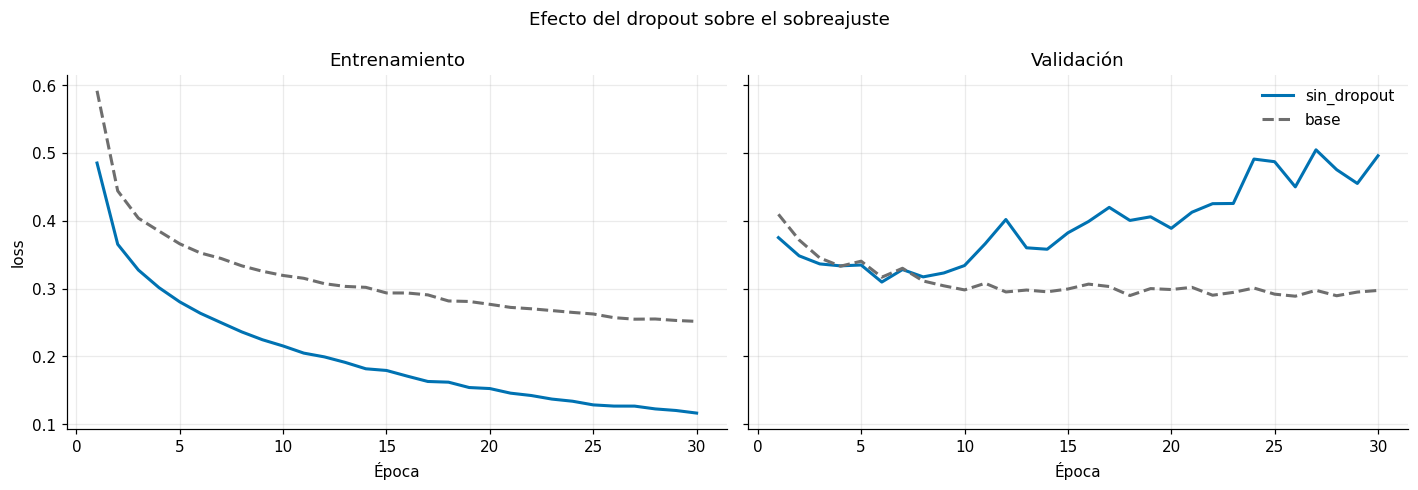

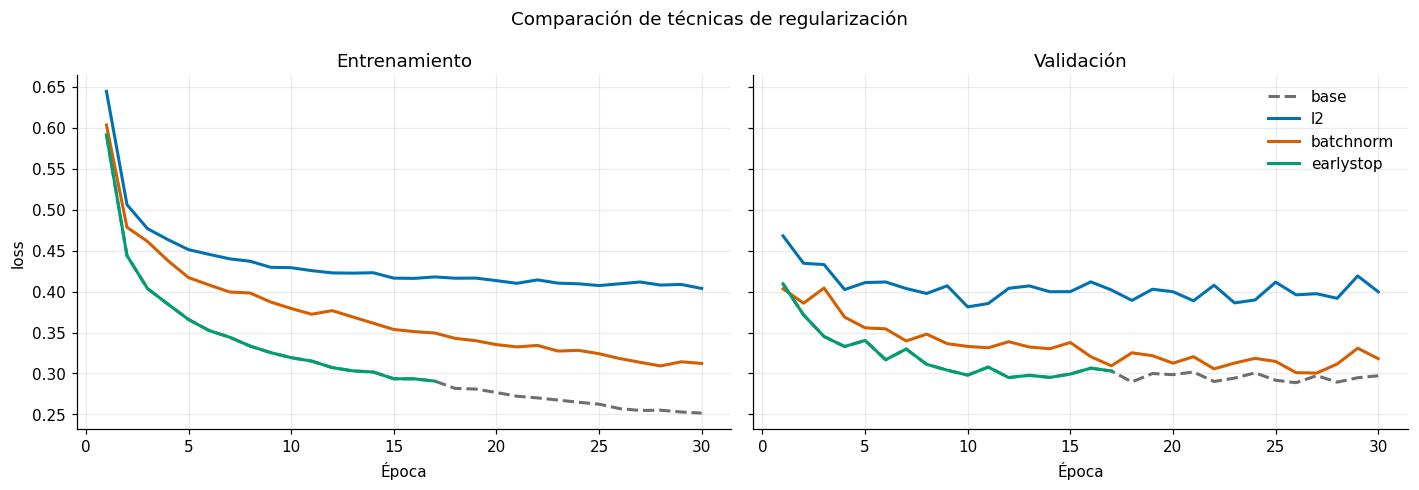

,experimento,config,val_acc_max,val_loss_min,mejor_epoca,train_acc_final,brecha,epocas
0,base,256-128 | relu | dropout 0.3 | lr 0.001 | batc...,0.8970,0.2888,26,0.9050,0.0080,30
0,sin_dropout,sin dropout,0.8958,0.3096,6,0.9559,0.0644,30
1,earlystop,dropout 0.3 + early stopping (máx. 50 épocas),0.8952,0.2950,12,0.8907,-0.0012,17
2,l2,dropout 0.3 + L2 1e-4,0.8903,0.3813,10,0.8792,-0.0066,30
3,batchnorm,dropout 0.3 + BatchNormalization,0.8902,0.3005,27,0.8827,0.0002,30


In [35]:
# Gráfico exigido por la pauta: comportamiento con y sin regularización
comparar(['sin_dropout', 'base'], 'Efecto del dropout sobre el sobreajuste', metrica='loss')

comparar(['base', 'l2', 'batchnorm', 'earlystop'],
         'Comparación de técnicas de regularización', metrica='loss')

pd.concat([tabla('0-base'), tabla('6-regularizacion')])[
    ['experimento', 'config', 'val_acc_max', 'val_loss_min', 'mejor_epoca',
     'train_acc_final', 'brecha', 'epocas']]

### Análisis del experimento 6

**Resultados:**

| Configuración | `val_acc_max` | `val_loss_min` (época) | `train_acc_final` | `brecha` | Tiempo |
|---|---|---|---|---|---|
| Sin dropout | 0.8958 | 0.3096 (6) | **0.9559** | **0.0644** | 77 s |
| Dropout 0.3 (base) | **0.8970** | 0.2888 (26) | 0.9050 | 0.0080 | ≈ 85 s |
| Dropout + L2 | 0.8903 | - * | 0.8792 | -0.0066 | 87 s |
| Dropout + BatchNorm | 0.8902 | 0.3005 (27) | 0.8827 | 0.0002 | 98 s |
| Dropout + early stopping | 0.8952 | 0.2950 (12) | 0.8907 | -0.0012 | 49 s (17 épocas) |

<sub>\* La pérdida con L2 incluye la penalización de los pesos, así que no se compara con las
demás.</sub>

- El `val_acc_max` de "sin dropout" (0.8958) queda cerca del base (0.8970) — a simple vista no
  parece un problema grave. Pero la **brecha** (la métrica que realmente mide sobreajuste) es 8
  veces mayor que la del base (0.0644 frente a 0.0080), y la mejor pérdida de validación aparece
  muy temprano (época 6): desde ahí la pérdida de validación empeora durante 24 épocas más,
  mientras la de entrenamiento sigue bajando hasta un accuracy de 0.9559. El accuracy máximo de
  validación no muestra el sobreajuste con la misma claridad que la brecha y la curva de pérdida.
- L2 junto con dropout regulariza de más: el accuracy de entrenamiento ni siquiera llega a 0.88 y
  la brecha es negativa.
- BatchNorm iguala casi al base en brecha (0.0002) pero con menor accuracy, y tarda un 15% más.
- Early stopping se detuvo en la época 17 con los pesos de la 12. Ahorró más de la mitad del
  tiempo (49 s frente a ≈ 85 s) y quedó a solo 0.18 puntos del base.

**¿Se cumplió lo esperado?** Sí para el dropout, aunque la diferencia se ve mejor en la brecha y
en la curva de pérdida que en el accuracy máximo. L2 y BatchNorm no aportaron sobre el dropout
solo.

**Decisión:** dropout 0.3 con early stopping, sin L2 ni BatchNorm. Con batch 128 las curvas son
más suaves, así que es menos probable que el early stopping se detenga antes de tiempo.

## 12. Experimento 7: Arquitectura de la red

**Hipótesis:** La profundidad y el ancho determinan la capacidad del modelo, es decir, la
complejidad de las funciones que puede representar.

- **Una capa de 128 neuronas** debería quedar por debajo del base, eso significa capacidad insuficiente para
  separar clases visualmente similares.
- **Tres capas de 512-256-128** ofrecen más capacidad, pero también más oportunidad de memorizar
  el conjunto de entrenamiento. Todo depende si la regularización logra contener
  el sobreajuste.

Más parámetros no significan mejor generalización, ya que el criterio de selección es el desempeño en validación, no la capacidad nominal.

In [36]:
model_1capa, history_1capa = run_experiment(
    nombre='1capa', bloque='7-arquitectura', modelo=build_model(units=(128,)),
    config='1 capa oculta: 128'
)

model_3capas, history_3capas = run_experiment(
    nombre='3capas', bloque='7-arquitectura', modelo=build_model(units=(512, 256, 128)),
    config='3 capas ocultas: 512-256-128'
)

1capa          val_acc_max=0.9003  val_loss_min=0.2933 (época 15)  64s
3capas         val_acc_max=0.8965  val_loss_min=0.2936 (época 28)  155s


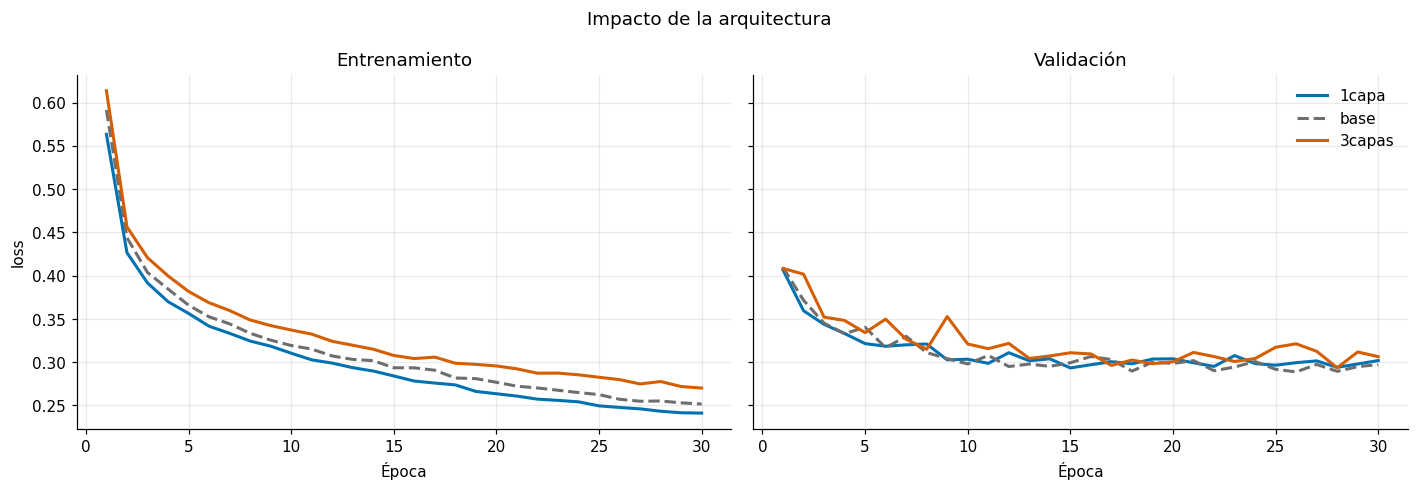

1capa     101,770 parámetros
base      235,146 parámetros
3capas    567,434 parámetros


,experimento,config,val_acc_max,train_acc_final,brecha
0,base,256-128 | relu | dropout 0.3 | lr 0.001 | batc...,0.8970,0.9050,0.0080
0,1capa,1 capa oculta: 128,0.9003,0.9067,0.0091
1,3capas,3 capas ocultas: 512-256-128,0.8965,0.9011,0.0064


In [37]:
comparar(['1capa', 'base', '3capas'], 'Impacto de la arquitectura', metrica='loss')

# Cantidad de parámetros de cada arquitectura, para relacionar capacidad y desempeño
for nombre, m in [('1capa', model_1capa), ('base', model), ('3capas', model_3capas)]:
    print(f"{nombre:<7} {m.count_params():>9,} parámetros")

pd.concat([tabla('0-base'), tabla('7-arquitectura')])[
    ['experimento', 'config', 'val_acc_max', 'train_acc_final', 'brecha']]

### Análisis del experimento 7

**Resultados:**

| Arquitectura | Parámetros | `val_acc_max` | `brecha` | Tiempo |
|---|---|---|---|---|
| 1 capa (128) | 101.770 | **0.9003** | 0.0091 | 64 s |
| 2 capas: 256-128 (base) | 235.146 | 0.8970 | 0.0080 | ≈ 85 s |
| 3 capas: 512-256-128 | 567.434 | 0.8965 | **0.0064** | 155 s |

- Con menos de la mitad de los parámetros del base, una sola capa **supera** al base y a la
  arquitectura de tres capas.
- Con 2,4 veces más parámetros, tres capas no solo no mejoran: quedan últimas en accuracy y
  tardan casi el doble que el base.
- Las tres arquitecturas quedan dentro de un rango de apenas 0.38 puntos (0.8965 a 0.9003).

**¿Se cumplió lo esperado?** No. Se esperaba que una capa rindiera peor por tener menos
capacidad, y en cambio fue la que mejor rindió; y se esperaba que tres capas pudieran aprovechar
su mayor capacidad, y en cambio no mejoraron nada.

**Interpretación:** el desempeño no está limitado por la capacidad de la red. El límite, cercano
al 90% en validación, viene de aplanar la imagen: se pierde la información espacial y ni quitar
ni agregar neuronas lo cambia de forma relevante.

**Decisión:** se mantiene 256-128, para que las diferencias del modelo final vengan de los
cambios que sí tuvieron un efecto más consistente (batch y regularización). Una capa sería una
alternativa igual de válida y bastante más liviana y rápida de entrenar.

## 13. Tabla comparativa global

Resumen de todas las configuraciones evaluadas. Es la evidencia que respalda la selección de los
hiperparámetros del modelo final.

In [38]:
resumen = tabla()
resumen

,experimento,bloque,config,val_acc_max,val_loss_min,mejor_epoca,train_acc_final,brecha,epocas,seg
0,batch_512,2-batch_size,batch 512,0.9048,0.2696,23,0.9136,0.0121,30,17.0
1,batch_128,2-batch_size,batch 128,0.9042,0.2784,24,0.9126,0.0084,30,33.5
2,lr_bajo,1-learning_rate,lr 0.0001,0.9040,0.2670,29,0.9126,0.0086,30,86.1
3,epocas_50,3-epocas,50 épocas,0.9035,0.2888,26,0.9184,0.0191,50,145.4
4,sigmoid,4-activacion,activación sigmoid,0.9033,0.2679,26,0.9158,0.0183,30,84.3
5,elu,4-activacion,activación elu,0.9018,0.2821,30,0.9052,0.0034,30,83.9
6,1capa,7-arquitectura,1 capa oculta: 128,0.9003,0.2933,15,0.9067,0.0091,30,63.9
7,mse,5-perdida,pérdida MSE con etiquetas one-hot,0.8978,0.0146,27,0.9015,0.0069,30,84.0
8,base,0-base,256-128 | relu | dropout 0.3 | lr 0.001 | batc...,0.8970,0.2888,26,0.9050,0.0080,30,NaN
9,batch_16,2-batch_size,batch 16,0.8968,0.2997,18,0.8954,-0.0015,30,130.5


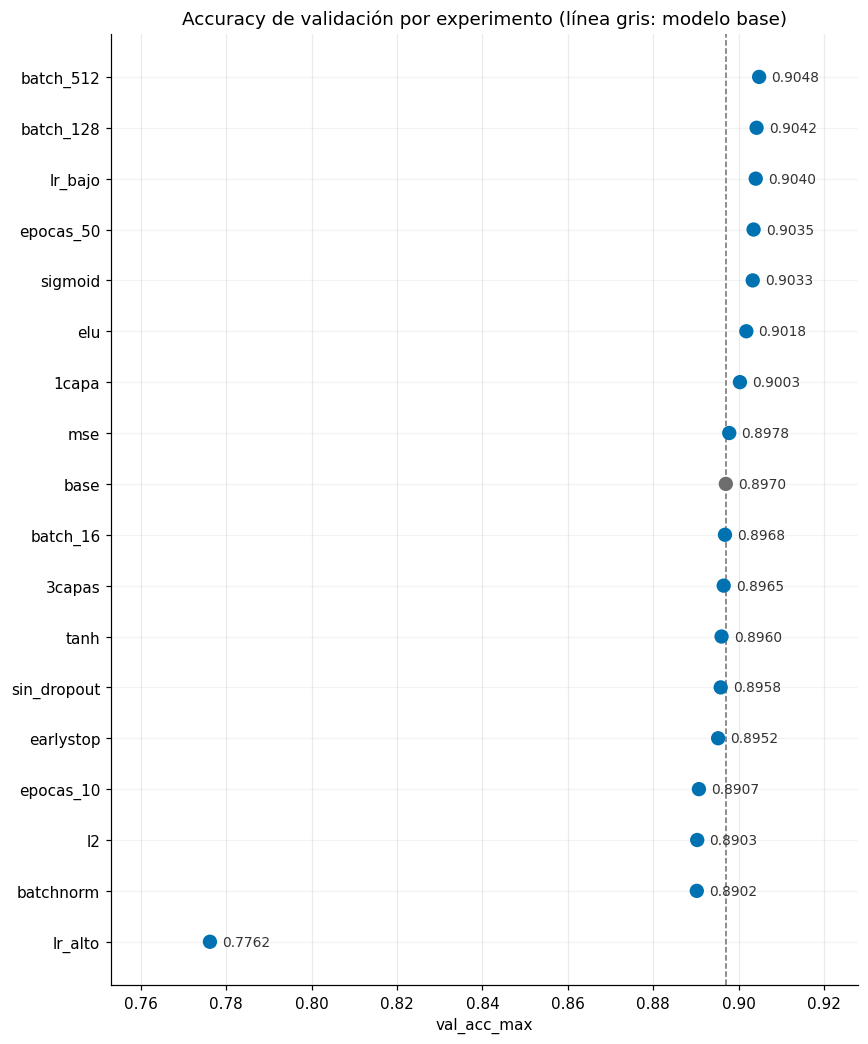

In [39]:
resumen_puntos(resumen, 'Accuracy de validación por experimento (línea gris: modelo base)')

### Análisis de la tabla global

- La tasa de aprendizaje es el hiperparámetro con más impacto: con `0.01` el accuracy cae más de
  12 puntos (0.7762). Ninguna otra configuración se aleja más de 0.8 puntos del base.
- Sin ese caso, las 17 configuraciones quedan entre 0.8902 y 0.9048, un rango de 1.46 puntos. El
  MLP se acerca a un límite cercano al 90% en validación, sin importar mucho qué hiperparámetro se
  ajuste.
- Las mejores configuraciones cambian el batch (512 y 128), la tasa de aprendizaje (0.0001), las
  épocas (50) o la activación (sigmoid), y superan al base por entre 0.33 y 0.78 puntos.
- Las peores, sin contar `lr_alto`, son BatchNorm, L2 y 10 épocas — ninguna se aleja más de 0.7
  puntos del base.
- Como cada configuración se entrenó con una sola semilla, diferencias menores a 0.5 puntos
  pueden ser azar. Por eso el modelo final no se arma solo mirando el accuracy de validación: se
  prioriza ELU por su brecha baja, batch 128 por su velocidad, y dropout con early stopping por
  la evidencia clara de sobreajuste que muestra el experimento 6.

## 14. Modelo final

La configuración final toma la mejor opción de cada experimento:

| Decisión | Valor | Experimento | Motivo |
|---|---|---|---|
| Tasa de aprendizaje | 0.001 | 1 | 0.01 no converge y 0.0001 quedaría subentrenado con batch 128 |
| Batch | 128 | 2 | Mejor accuracy de validación (0.9052) y 2,5 veces más rápido |
| Épocas | Hasta 50, con early stopping | 3 y 6 | La validación se estanca desde la época 15 |
| Activación | ELU | 4 | Mejor accuracy de su grupo y menor brecha |
| Pérdida | Entropía cruzada | 5 | Converge más rápido al inicio |
| Regularización | Dropout 0.3 | 6 | Bajó la brecha de 0.066 a 0.007. L2 y BatchNorm no aportaron |
| Arquitectura | 256-128 | 7 | Las tres arquitecturas rindieron igual |

Este es el único modelo que se evalúa en el test durante la etapa experimental.

In [40]:
# ---- Configuración final: justificada en la tabla anterior ----
FINAL = dict(
    units=(256, 128),     # experimento 7
    activation='elu',     # experimento 4
    dropout=0.3,          # experimento 6
    l2=0.0,               # experimento 6
    batchnorm=False,      # experimento 6
)
FINAL_LR = 0.001          # experimento 1
FINAL_BATCH = 128         # experimento 2
FINAL_EPOCHS = 50         # experimento 3; el early stopping decide cuándo detener

model_final, history_final = run_experiment(
    nombre='final', bloque='8-final', modelo=build_model(**FINAL),
    learning_rate=FINAL_LR, batch_size=FINAL_BATCH, epochs=FINAL_EPOCHS,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    config=f'{FINAL} | lr {FINAL_LR} | batch {FINAL_BATCH} | early stopping'
)

final          val_acc_max=0.9025  val_loss_min=0.2715 (época 25)  34s


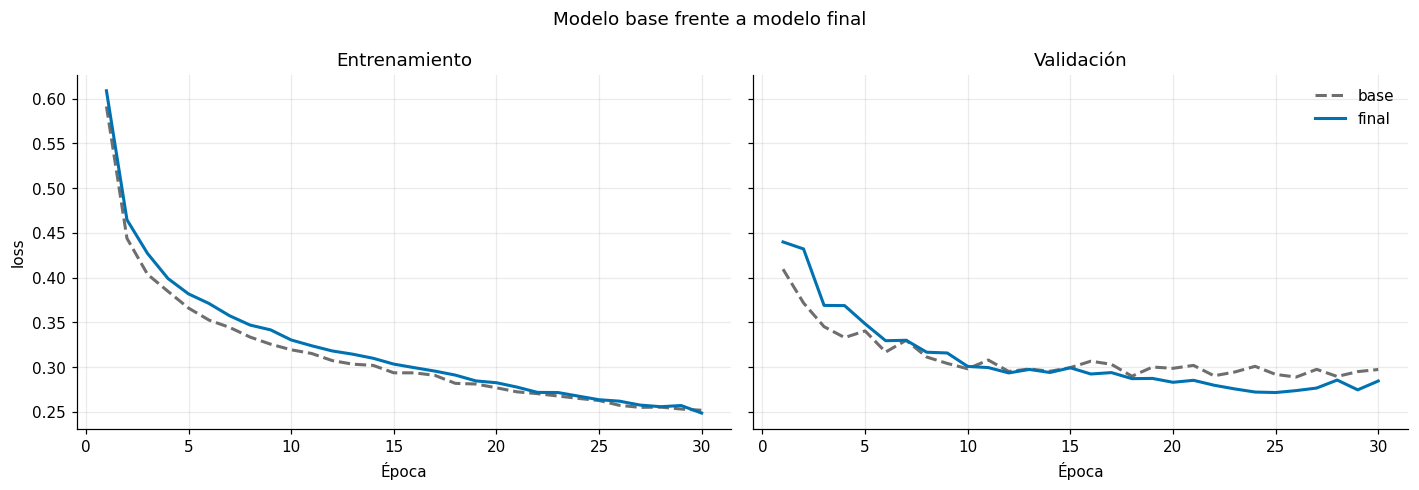

In [41]:
comparar(['base', 'final'], 'Modelo base frente a modelo final', metrica='loss')

### 14.1 Evaluación sobre el conjunto de prueba

Se comparan el modelo base y el final sobre las mismas 10.000 imágenes de prueba.

In [42]:
for nombre, m in [('base', model), ('final', model_final)]:
    loss_t, acc_t = m.evaluate(X_test, y_test, verbose=0)
    print(f"{nombre:<6} test_accuracy={acc_t:.4f}  test_loss={loss_t:.4f}")

base   test_accuracy=0.8829  test_loss=0.3505
final  test_accuracy=0.8877  test_loss=0.3207


In [43]:
y_pred_final = np.argmax(model_final.predict(X_test, verbose=0), axis=1)
y_pred_base = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(classification_report(y_test, y_pred_final, target_names=class_names, digits=3))

              precision    recall  f1-score   support

 T-shirt/top      0.872     0.828     0.849      1000
     Trouser      0.994     0.968     0.981      1000
    Pullover      0.826     0.755     0.789      1000
       Dress      0.863     0.914     0.888      1000
        Coat      0.788     0.832     0.809      1000
      Sandal      0.977     0.959     0.968      1000
       Shirt      0.697     0.727     0.712      1000
     Sneaker      0.930     0.968     0.949      1000
         Bag      0.977     0.976     0.976      1000
  Ankle boot      0.967     0.950     0.959      1000

    accuracy                          0.888     10000
   macro avg      0.889     0.888     0.888     10000
weighted avg      0.889     0.888     0.888     10000



In [44]:
# Cuadro resumen de métricas por clase: precision, recall, F1 y soporte
rep_final = classification_report(y_test, y_pred_final, target_names=class_names,
                                  output_dict=True, zero_division=0)
metricas_final = pd.DataFrame(rep_final).T[['precision', 'recall', 'f1-score', 'support']].round(3)
metricas_final

,precision,recall,f1-score,support
T-shirt/top,0.872,0.828,0.849,1000.000
Trouser,0.994,0.968,0.981,1000.000
Pullover,0.826,0.755,0.789,1000.000
Dress,0.863,0.914,0.888,1000.000
Coat,0.788,0.832,0.809,1000.000
Sandal,0.977,0.959,0.968,1000.000
Shirt,0.697,0.727,0.712,1000.000
Sneaker,0.930,0.968,0.949,1000.000
Bag,0.977,0.976,0.976,1000.000
Ankle boot,0.967,0.950,0.959,1000.000


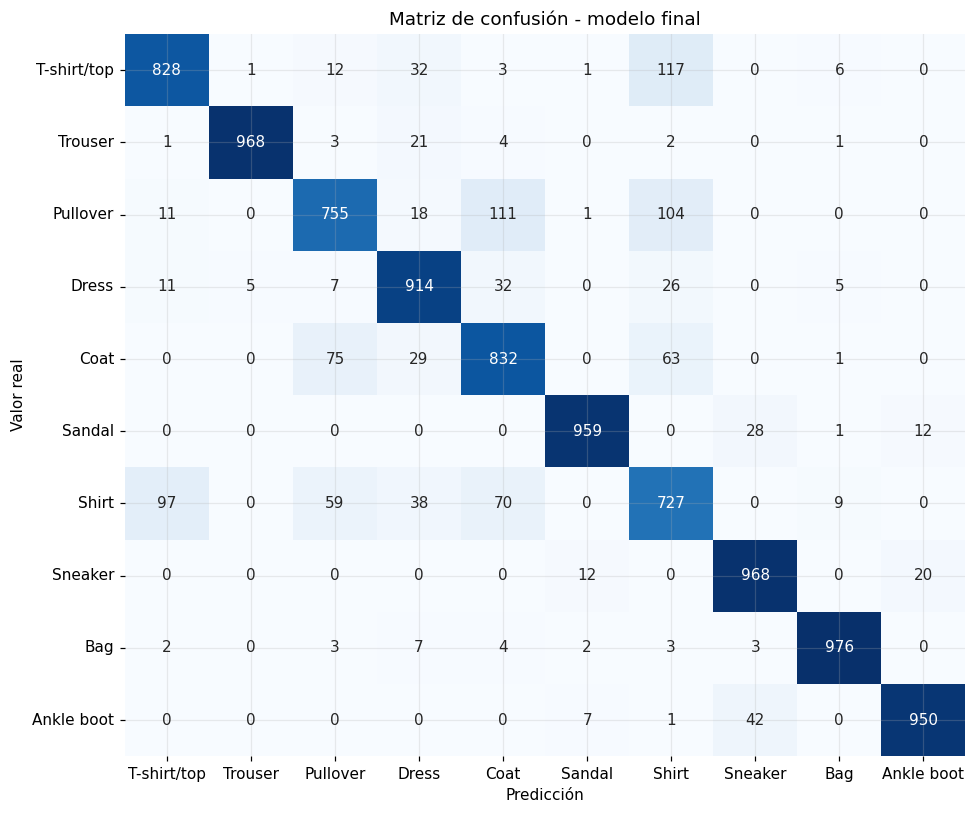

In [45]:
# Matriz de confusión del modelo final: escala secuencial de un solo tono,
# donde la intensidad representa la cantidad de casos
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(9, 7.5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - modelo final')
plt.tight_layout()
plt.show()

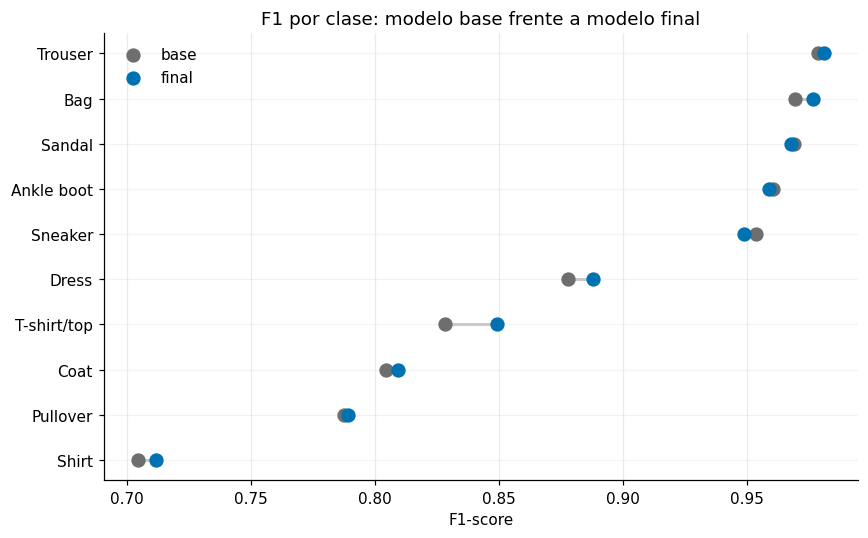

,clase,base,final
6,Shirt,0.704,0.712
2,Pullover,0.788,0.789
4,Coat,0.804,0.809
0,T-shirt/top,0.828,0.849
3,Dress,0.878,0.888
7,Sneaker,0.953,0.949
9,Ankle boot,0.960,0.959
5,Sandal,0.969,0.968
8,Bag,0.969,0.976
1,Trouser,0.978,0.981


In [46]:
# F1 por clase: modelo base frente a modelo final
rep_base = classification_report(y_test, y_pred_base, target_names=class_names,
                                 output_dict=True, zero_division=0)
f1 = pd.DataFrame({
    'clase': class_names,
    'base': [rep_base[c]['f1-score'] for c in class_names],
    'final': [rep_final[c]['f1-score'] for c in class_names],
}).sort_values('final')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(f1['clase'], f1['base'], f1['final'], color='#CCCCCC', lw=2, zorder=1)
ax.scatter(f1['base'], f1['clase'], color=GRIS_REF, s=70, label='base', zorder=3)
ax.scatter(f1['final'], f1['clase'], color=PALETA[0], s=70, label='final', zorder=3)
ax.set_xlabel('F1-score')
ax.set_title('F1 por clase: modelo base frente a modelo final')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.15)
fig.tight_layout()
plt.show()

f1.round(3)

### Análisis de la evaluación final

**Métricas en el conjunto de prueba:**

| Modelo | Accuracy | Pérdida | F1 macro | Tiempo de entrenamiento |
|---|---|---|---|---|
| Base | 0.8829 | 0.3505 | 0.88 | ≈ 85 s |
| Final | **0.8877** | **0.3207** | **0.888** | **34 s** |

- El modelo final mejora +0.48 puntos de accuracy, tiene una pérdida menor y entrena en menos de
  la mitad del tiempo (34 s frente a ≈ 85 s), gracias sobre todo al batch 128 y al early stopping.
- El early stopping tomó los pesos de la época 25.
- El accuracy de test (0.8877) queda 1.48 puntos bajo el mejor accuracy de validación (0.9025).
  Es normal, porque la configuración se eligió mirando la validación, no el test.
- El modelo final (0.9025 en validación) queda apenas por debajo del mejor experimento individual
  (batch 512 solo, con 0.9048): combinar varios cambios a la vez no siempre suma, y con una sola
  semilla hay algo de ruido de por medio.

**Por clase (F1-score, base → final):**

- Mejoran: T-shirt/top (0.828 → 0.849), Dress (0.878 → 0.888), Bag (0.969 → 0.976), Coat
  (0.804 → 0.809), Shirt (0.704 → 0.712), Trouser (0.978 → 0.981).
- Prácticamente sin cambio: Pullover (0.788 → 0.789).
- Empeoran levemente: Sneaker (0.953 → 0.949), Ankle boot (0.960 → 0.959), Sandal
  (0.969 → 0.968).
- Shirt sigue siendo la clase más difícil (F1 0.712), seguida de Pullover (0.789) y Coat (0.809)
  — las mismas tres que ya destacaban como débiles en el modelo base.

**Interpretación:** el modelo final mejora de forma pareja en la mayoría de las clases, con la
mayor ganancia en T-shirt/top, pero no resuelve la dificultad de fondo con Shirt, Pullover y
Coat. Esto es consistente con el experimento 7: el modelo ya está cerca del límite que permite
la imagen aplanada, así que ajustar hiperparámetros mejora el desempeño general sin cambiar
cuáles son las clases más difíciles.

## 15. Conclusiones

1. **Hiperparámetros:** la tasa de aprendizaje fue la que más afectó, ya que con 0.01 el modelo
   no converge (accuracy de validación de solo 0.7762). El batch 128 (empatado con 512) fue el
   cambio más útil entre los que sí ayudaron, porque mejoró el accuracy y redujo el tiempo a menos
   de un tercio. Con 50 épocas la validación deja de mejorar después de la época 26, por eso se
   usa early stopping en el modelo final.
2. **Funciones:** softmax con entropía cruzada es la combinación adecuada para clases
   excluyentes, aunque en esta corrida MSE terminó con un accuracy prácticamente igual (diferencia
   de 0.0008). En las capas ocultas, sigmoid tuvo el mejor accuracy puntual, pero con la mayor
   brecha del grupo; ELU quedó segundo en accuracy con una brecha mucho más baja, por lo que se
   elige como mejor equilibrio entre desempeño y generalización.
3. **Regularización:** el dropout fue la técnica más efectiva, aunque el efecto se nota más en la
   brecha entrenamiento-validación (8 veces mayor sin dropout) y en que la pérdida de validación
   empieza a empeorar desde la época 6 sin él, que en el accuracy máximo de validación por sí
   solo. L2 y BatchNorm no aportaron sobre el dropout solo.
4. **Desempeño final:** el modelo final (batch 128, ELU, dropout 0.3 y early stopping) logró
   88.77% de accuracy en test y un F1 macro de 0.888, frente a 88.29% y 0.88 del base, con menor
   pérdida y menos de la mitad del tiempo de entrenamiento. Las prendas con forma distintiva
   superan un F1 de 0.95, mientras que Shirt (0.71), Pullover (0.79) y Coat (0.81) siguen siendo
   las más difíciles.
5. **Límite del MLP:** sin contar la tasa de aprendizaje alta, todas las configuraciones quedaron
   en un rango de 1.46 puntos, y ni triplicar ni reducir a la mitad los parámetros cambió el
   resultado de forma relevante — de hecho, la arquitectura con menos parámetros (1 capa) fue la
   que mejor rindió de las tres. El límite viene de aplanar la imagen, que elimina la información
   espacial. Una red convolucional (CNN) sería el siguiente paso lógico.
6. **Nota metodológica:** al repetir el entrenamiento completo, los resultados cambiaban
   levemente entre una corrida y otra a pesar de fijar una semilla, porque TensorFlow no es
   determinista por defecto en algunas operaciones. Activar
   `tf.config.experimental.enable_op_determinism()` resolvió esto: los resultados reportados aquí
   se reproducen de forma idéntica al volver a ejecutar el notebook completo desde cero.
7. **Mejoras propuestas:**
   - Repetir los experimentos con varias semillas para separar las diferencias reales del azar.
   - Entrenar con `learning_rate = 0.0001` y batch 128 juntos, con más épocas.
   - Usar `class_weight` o aumento de datos para reforzar la clase Shirt.
   - Probar una CNN.